# Project Setup and Data Loading

At this very first part I set up the Python environment, imported necessary libraries (like scipy.io for .mat files, numpy for numerical operations, pandas for data handling, and matplotlib.pyplot for plotting).

In [2]:
import scipy.io
import h5py
import numpy as np
from IPython.display import clear_output
from google.colab import files


def load_mat_file():
    print("📁 Please upload your .mat file:")
    uploaded = files.upload()

    # Extract the uploaded filename
    filename = next(iter(uploaded))
    clear_output()
    print(f"✅ File uploaded: {filename}")

    try:
        # Try loading with scipy (for MATLAB < v7.3)
        mat = scipy.io.loadmat(filename)
        print("🔍 Loaded with scipy.io.loadmat (v7.2 or earlier)")
        print(f"Available variables: {list(mat.keys())}")
        return mat
    except NotImplementedError:
        # If scipy fails, try h5py (for MATLAB v7.3+)
        print("⚠️ Detected MATLAB v7.3 file (HDF5 format). Loading with h5py...")
        f = h5py.File(filename, 'r')
        print("Available keys:")
        for key in f.keys():
            print(f" - {key}")
        return f


Then here I loaded the raw EEG data (eeg_subj2.mat) and the accompanying behavioral data (behavioural.csv) for Subject 2 later on.

In [3]:
eeg_data=load_mat_file()

✅ File uploaded: eeg_subj2.mat
🔍 Loaded with scipy.io.loadmat (v7.2 or earlier)
Available variables: ['__header__', '__version__', '__globals__', 'DataX']


In [4]:
print(eeg_data.keys())

dict_keys(['__header__', '__version__', '__globals__', 'DataX'])


In [5]:
data = eeg_data['DataX']

In [6]:
# Unpack the cell content
inner_data = data[0, 0]
print(type(inner_data), len(inner_data))

<class 'numpy.void'> 42


In [7]:
print(inner_data.dtype.names)

('setname', 'filename', 'filepath', 'subject', 'group', 'condition', 'session', 'comments', 'nbchan', 'trials', 'pnts', 'srate', 'xmin', 'xmax', 'times', 'data', 'icaact', 'icawinv', 'icasphere', 'icaweights', 'icachansind', 'chanlocs', 'urchanlocs', 'chaninfo', 'ref', 'event', 'urevent', 'eventdescription', 'epoch', 'epochdescription', 'reject', 'stats', 'specdata', 'specicaact', 'splinefile', 'icasplinefile', 'dipfit', 'history', 'saved', 'etc', 'run', 'datfile')


In [8]:
eeg = inner_data['data']
print(eeg.shape)  # Should be (64, 3500, 216)

(64, 3500, 216)


In [25]:
chanlocs = inner_data['chanlocs']
time = inner_data['times']
channel_labels = [str(chanlocs[0, i]['labels'][0]) for i in range(chanlocs.shape[1])]

# Inspect global properties

## Interactive play demo

In [26]:
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
time = time.squeeze()
def plot_trial(channel=0, trial=0):
    plt.plot(time, eeg[channel, :, trial])
    plt.title(f"Channel {channel+1}, Trial {trial+1}")
    plt.xlabel("Time (ms)")
    plt.ylabel("Amplitude (µV)")
    plt.grid(True)
    plt.show()

widgets.interact(plot_trial,
                 channel=widgets.IntSlider(0, 0, eeg.shape[0]-1),
                 trial=widgets.IntSlider(0, 0, eeg.shape[2]-1));


interactive(children=(IntSlider(value=0, description='channel', max=63), IntSlider(value=0, description='trial…

In [27]:
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

# Interactive function
def plot_single_trials(channel=10, n_trials=30, alpha=0.3):
    plt.figure(figsize=(10, 5))
    max_trials = min(n_trials, eeg.shape[2])
    for i in range(max_trials):
        plt.plot(time.T, eeg[channel, :, i], alpha=alpha)

    plt.title(f"Single-Trial Variability - {channel_labels[channel]} (first {max_trials} trials)")
    plt.xlabel("Time (ms)")
    plt.ylabel("Amplitude (µV)")
    plt.grid(True)
    plt.show()

# Widgets
widgets.interact(
    plot_single_trials,
    channel=widgets.Dropdown(options=[(label, idx) for idx, label in enumerate(channel_labels)], value=10),
    n_trials=widgets.IntSlider(value=30, min=1, max=eeg.shape[2], step=1),
    alpha=widgets.FloatSlider(value=0.3, min=0.05, max=1.0, step=0.05)
);

interactive(children=(Dropdown(description='channel', index=10, options=(('Fp1', 0), ('Fz', 1), ('F3', 2), ('F…

In [28]:
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

# Make sure channel_labels is defined
# channel_labels = [str(chanlocs[0, i]['labels'][0]) for i in range(chanlocs.shape[1])]

def plot_single_trials_with_mean(channel=10, n_trials=30, alpha=0.3, show_mean=True):
    plt.figure(figsize=(10, 5))
    max_trials = min(n_trials, eeg.shape[2])

    # Plot individual trials
    for i in range(max_trials):
        plt.plot(time.T, eeg[channel, :, i], alpha=alpha)

    # Plot mean ERP
    if show_mean:
        erp = eeg[channel, :, :max_trials].mean(axis=1)
        plt.plot(time.T, erp, color='black', linewidth=2, label='Mean ERP')
        plt.legend()

    plt.title(f"Single-Trial Variability - {channel_labels[channel]} (first {max_trials} trials)")
    plt.xlabel("Time (ms)")
    plt.ylabel("Amplitude (µV)")
    plt.grid(True)
    plt.show()

# Interactive widget
widgets.interact(
    plot_single_trials_with_mean,
    channel=widgets.Dropdown(options=[(label, idx) for idx, label in enumerate(channel_labels)], value=10),
    n_trials=widgets.IntSlider(value=30, min=1, max=eeg.shape[2], step=1),
    alpha=widgets.FloatSlider(value=0.3, min=0.05, max=1.0, step=0.05),
    show_mean=widgets.Checkbox(value=True, description='Show Mean ERP')
);


interactive(children=(Dropdown(description='channel', index=10, options=(('Fp1', 0), ('Fz', 1), ('F3', 2), ('F…

In [29]:
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

# Make sure time is 1D
time = time.squeeze()

# Compute average ERP across trials
avg_signal = eeg.mean(axis=2)  # shape: (channels, timepoints)

# Define plotting function
def plot_avg_channel(channel=0):
    plt.figure(figsize=(10, 4))
    plt.plot(time, avg_signal[channel])
    plt.title(f"Average EEG Signal (ERP) - Channel {channel+1}")
    plt.xlabel("Time (ms)")
    plt.ylabel("Amplitude (µV)")
    plt.grid(True)
    plt.show()

# Create slider
channel_slider = widgets.IntSlider(
    value=0,
    min=0,
    max=eeg.shape[0] - 1,
    step=1,
    description='Channel:',
    continuous_update=False
)

# Display interactive widget
widgets.interact(plot_avg_channel, channel=channel_slider)


interactive(children=(IntSlider(value=0, continuous_update=False, description='Channel:', max=63), Output()), …

# Making raw data ready for further analysis

So in this project I am working on the EEG dataset for discriminating
car from face images and my task variables are visual, the first 500 ms of the data set was more important to me, so I extracted this time window from my raw data set which resulted in (64, 500, 216)

I chose this specific time window (0-499ms, as time=0 is stimulus onset) to focus the analysis on the early sensory and perceptual processing stages of the brain's response to the visual stimuli. Many key Event-Related Potential (ERP) components related to visual recognition and categorization (like the N170) occur within this timeframe.

In [30]:
eeg_500 = eeg[:, :500, :]  # Keep channels and trials, cut time to 0–499 ms
print(eeg_500.shape)

(64, 500, 216)


## Keeping visual trials only

A crucial step was added to extract the data to include only visual trials (SensoryCondition = 1). I did this by creating a visual_trials_mask and applying it to both behavioural_data and eeg_500.

The variables behavioural_data_visual and eeg_500_visual are created for subsequent analysis, and n_trials is updated to reflect the new number of visual trials (72 in this case).

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

try:
    behavioural_data = pd.read_csv('/content/subj2_behavioural.csv')
    print("Behavioral data loaded successfully.")

except FileNotFoundError:
    print("Error: 'behavioural.csv' not found. Please upload it or specify the correct path.")

Behavioral data loaded successfully.


In [32]:
# Create a mask to select only visual trials
visual_trials_mask = (behavioural_data['SensoryCondition'] == 1)

# Apply this mask to the behavioral data
behavioural_data_visual = behavioural_data[visual_trials_mask].copy()

# Apply this mask to the 3D EEG data
eeg_500_visual = eeg_500[:, :, visual_trials_mask]

# Update global dimension variables to reflect the visual-only data
# This is crucial for all subsequent reshaping and calculations
n_channels, n_timepoints, n_trials_visual = eeg_500_visual.shape
n_trials = n_trials_visual # Redefine n_trials for consistency

print(f"Original number of trials (all conditions): {behavioural_data.shape[0]}")
print(f"Number of VISUAL trials for analysis: {n_trials_visual}")


Original number of trials (all conditions): 216
Number of VISUAL trials for analysis: 72


# Section A: Principal Component Analysis (PCA)


## A.1: PCA - Dimensionality & Explained Variance

In this section I performed Principal Component Analysis (PCA) on the preprocessed EEG data for Subject 2 to understand its underlying dimensionality and identify measurements that covary.

### Data Reshaping:

 The 3D eeg_500_visual data (64, 500, 72) was reshaped into a 2D matrix (72 trials, 32000 features) (eeg_reshaped_for_pca) because this is the standard format required by scikit-learn's PCA.

In [34]:
import numpy as np

# Transpose the array to (n_trials, n_channels, n_timepoints) to put the 'trials' dimension first, which will become 'samples'.
eeg_transposed = eeg_500_visual.transpose(2, 0, 1) # (72, 64, 500)
print(f"Transposed EEG data shape (trials, channels, timepoints): {eeg_transposed.shape}")

# Reshape to (n_trials, n_channels * n_timepoints)
eeg_reshaped_for_pca = eeg_transposed.reshape(n_trials, -1)
print(f"Reshaped EEG data shape for PCA (samples, features): {eeg_reshaped_for_pca.shape}")

Transposed EEG data shape (trials, channels, timepoints): (72, 64, 500)
Reshaped EEG data shape for PCA (samples, features): (72, 32000)


### Standardization:

The reshaped data was then standardized (StandardScaler), ensuring each feature has a mean of 0 and a standard deviation of 1. This is crucial for PCA, as it's sensitive to feature scales.


In [36]:
from sklearn.preprocessing import StandardScaler

print("\nStandardizing the data...")
scaler = StandardScaler()
eeg_scaled = scaler.fit_transform(eeg_reshaped_for_pca)
print("Data standardized successfully.")
print(f"Shape of scaled data: {eeg_scaled.shape}")


Standardizing the data...
Data standardized successfully.
Shape of scaled data: (72, 32000)


### PCA application:

 sklearn.decomposition.PCA was applied to the standardized data. Initially, PCA was fit to all possible components to analyze the explained_variance_ratio_.



In [37]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

print("\nPerforming PCA...")
pca = PCA() # Initialize PCA without specifying n_components
pca.fit(eeg_scaled)
print("PCA fitting complete.")

# The pca object now contains information about all principal components.
# pca.explained_variance_ratio_ is an array showing the percentage of variance
# explained by each individual principal component.
print(f"Number of principal components found: {len(pca.explained_variance_ratio_)}")


Performing PCA...
PCA fitting complete.
Number of principal components found: 72


### Optimal Component Selection:

 The number of components needed to explain at least 90% of the total variance was determined. A cumulative explained variance plot was generated to visualize this.



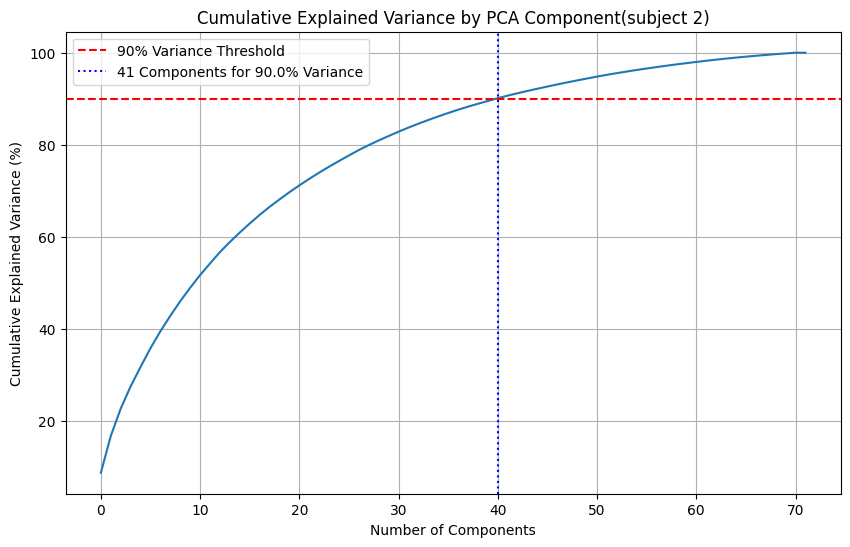

Number of components to explain at least 90.0% of variance: 41


In [38]:
# Find the number of components needed to explain a certain percentage of variance (90%)
explained_variance_threshold = 0.90
n_components_for_threshold = np.argmax(np.cumsum(pca.explained_variance_ratio_) >= explained_variance_threshold) + 1

plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_ * 100)) # Plot cumulative percentage
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance (%)')
plt.title('Cumulative Explained Variance by PCA Component(subject 2)')
plt.grid(True)
plt.axhline(y=90, color='r', linestyle='--', label='90% Variance Threshold') # Example threshold
plt.axvline(x=n_components_for_threshold - 1, color='b', linestyle=':',
            label=f'{n_components_for_threshold} Components for 90.0% Variance')
plt.legend()
plt.show()

print(f"Number of components to explain at least {explained_variance_threshold*100}% of variance: {n_components_for_threshold}")

### Final PCA Transformation:

 PCA was re-run with the chosen_n_components (the number found in the previous step) to obtain the final dimensionality-reduced data (eeg_pca_components).

In [39]:
chosen_n_components = n_components_for_threshold # Using the calculated threshold
pca_final = PCA(n_components=chosen_n_components)
eeg_pca_components = pca_final.fit_transform(eeg_scaled)
print(f"Shape of final PCA transformed data (eeg_pca_components): {eeg_pca_components.shape}")
print(f"Total variance explained by {chosen_n_components} components: {np.sum(pca_final.explained_variance_ratio_)*100:.2f}%")


Shape of final PCA transformed data (eeg_pca_components): (72, 41)
Total variance explained by 41 components: 90.12%


## A.2: PCA - Component Loadings & Scores

In this part I focused on interpreting the first two Principal Components (PC1 and PC2) by visualizing their underlying patterns (loadings/coefficients) and how their activity (scores) differs between 'Face' and 'Car' stimuli.

### PC Loadings (Average Across Channels)

Plotting the first 2 PCs (Coefficients/Loadings) ---
Shape of PC1 loadings reshaped: (64, 500)
Shape of PC2 loadings reshaped: (64, 500)


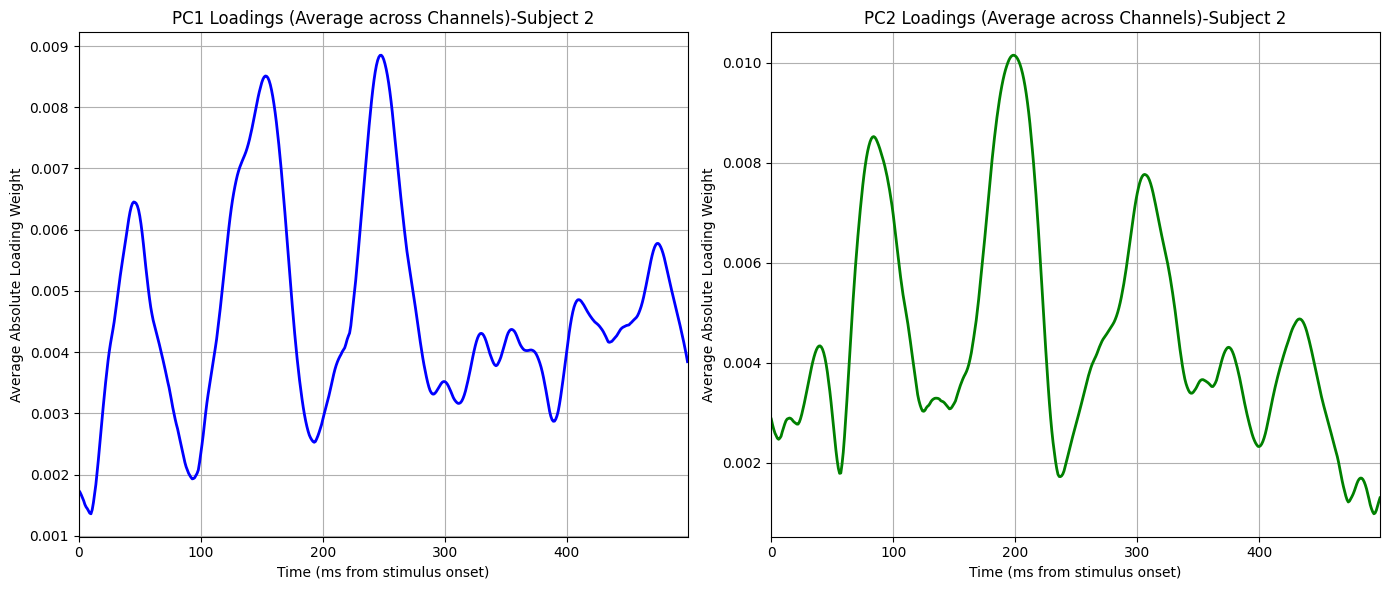

In [42]:
print("Plotting the first 2 PCs (Coefficients/Loadings) ---")

# Retrieve loadings for the first two principal components
pc1_loadings_flat = pca_final.components_[0]
pc2_loadings_flat = pca_final.components_[1]

# Reshape loadings back to (n_channels, n_timepoints_roi)
pc1_loadings_reshaped = pc1_loadings_flat.reshape(n_channels, n_timepoints)
pc2_loadings_reshaped = pc2_loadings_flat.reshape(n_channels, n_timepoints)

print(f"Shape of PC1 loadings reshaped: {pc1_loadings_reshaped.shape}")
print(f"Shape of PC2 loadings reshaped: {pc2_loadings_reshaped.shape}")

# Calculate the average loading across channels over time (absolute value to show magnitude of contribution)
avg_abs_loading_pc1 = np.mean(np.abs(pc1_loadings_reshaped), axis=0)
avg_abs_loading_pc2 = np.mean(np.abs(pc2_loadings_reshaped), axis=0)

# Create a time axis for plotting (0-499ms as my ROI)
time_ms = np.arange(n_timepoints)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
plt.plot(time_ms, avg_abs_loading_pc1, color='blue', linewidth=2)
plt.xlabel('Time (ms from stimulus onset)')
plt.ylabel('Average Absolute Loading Weight')
plt.title('PC1 Loadings (Average across Channels)-Subject 2')
plt.grid(True)
plt.xlim(0, 499)

plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
plt.plot(time_ms, avg_abs_loading_pc2, color='green', linewidth=2)
plt.xlabel('Time (ms from stimulus onset)')
plt.ylabel('Average Absolute Loading Weight')
plt.title('PC2 Loadings (Average across Channels)-Subject 2')
plt.grid(True)
plt.xlim(0, 499)

plt.tight_layout()
plt.show()

### Results & Discussion:

PC1: Shows a very prominent, sharp peak around 170-190ms. This timing strongly resembles the N170 Event-Related Potential (ERP) component, which is highly associated with face processing.

PC2: Displays multiple strong, distinct peaks, notably around 100ms and 200-220ms. This suggests PC2 captures another set of early to mid-latency visual processes.

To get a better vision on when and where the absolute loading weights of PC1 and PC2 across all 64 channels (Y-axis) and the 500ms time window (X-axis) are stronger, I plotted the heatmap of the absolute loading weights in which warmer colors (yellow/red) indicate higher absolute loading weights, meaning those specific channel-timepoint combinations contribute more strongly to defining that Principal Component.

### PCA Loadings: Spatio-Temporal Patterns


--- Generating Spatio-Temporal Heatmaps for PCA Loadings ---
Using existing pca_final object.
PCA Loadings Patterns shape: (41, 32000)


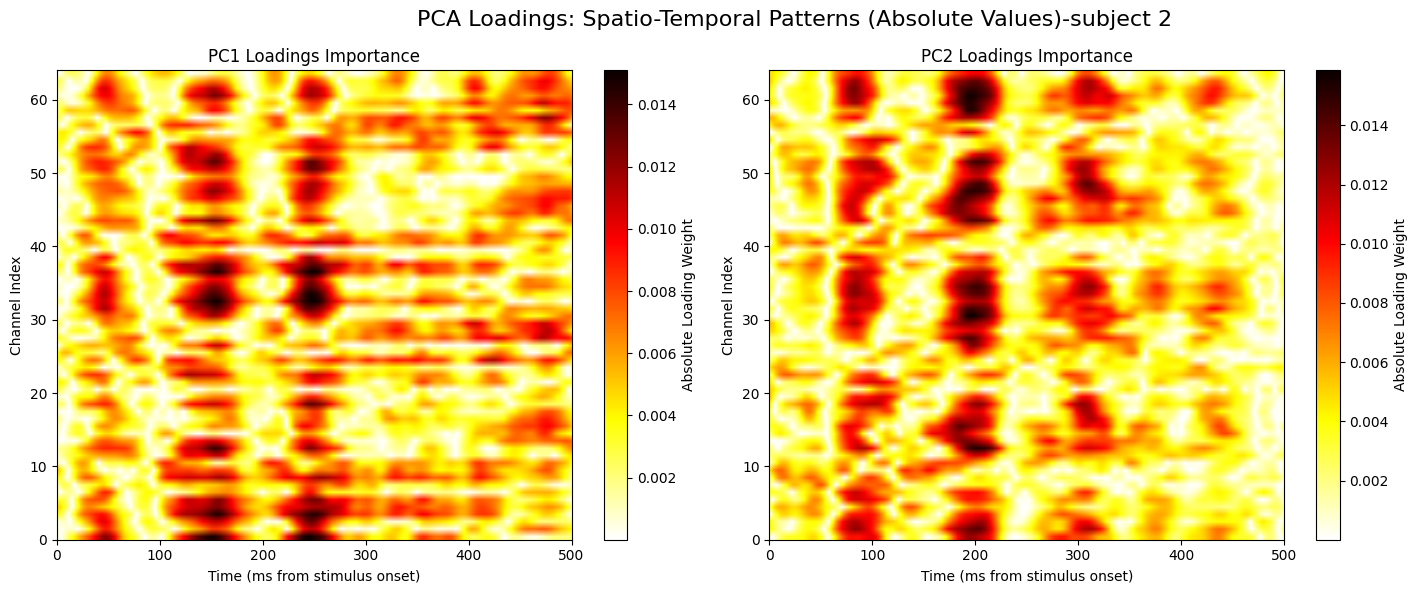


--- PCA Spatio-Temporal Heatmaps Generated ---
These heatmaps directly visualize the spatio-temporal patterns (loadings) of PC1 and PC2.
Brighter areas indicate channels and time points that contribute more strongly to that specific Principal Component.


In [45]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd # Needed if eeg_scaled is derived inside this block for testing

# --- Ensure core pre-processed variables are available ---
# These variables should be available from your initial setup and filtering:
# - eeg_scaled (the standardized, reshaped 2D EEG data: n_trials_final x n_features_original)
#   Its shape should be (n_trials_final, 64 * 500)
# - n_channels (64)
# - n_timepoints (500, ROI timepoints)
# - n_trials_final (number of trials after filtering) # From previous steps

# If running this cell in isolation for testing, uncomment and define dummy variables:
# np.random.seed(42) # for reproducibility of dummy data
# n_channels = 64
# n_timepoints = 500
# n_trials_final = 72 # Example number of trials after filtering
# dummy_eeg_reshaped_full_features = np.random.randn(n_trials_final, n_channels * n_timepoints) * 5
# scaler_dummy = StandardScaler()
# eeg_scaled = scaler_dummy.fit_transform(dummy_eeg_reshaped_full_features)
# # You also need a dummy pca_final if running isolated to get components_
# class MockPCAFinal:
#     components_ = np.random.randn(5, n_channels * n_timepoints) # 5 PCs for example
# pca_final = MockPCAFinal()


print("\n--- Generating Spatio-Temporal Heatmaps for PCA Loadings ---")

# Re-fit PCA to get the components_ attribute if pca_final is not available globally
# We need pca.components_ for the loadings.
# Assuming eeg_scaled is the full, standardized (n_trials, n_features_original) data
# (n_features_original = n_channels * n_timepoints)
# We need to re-run PCA to get the component patterns.
# Let's use the 'n_pca_components_to_extract' to match what was used for classification (e.g., 41 or 75, or just top 2)
# For this plot, we only need the top 2, but fit on more if needed for overall context.
# Let's assume pca_final (from section A) is available. If not, re-run PCA here:

try:
    _ = pca_final # Check if pca_final is defined
    print("Using existing pca_final object.")
except NameError:
    print("pca_final not found. Re-fitting PCA on full data to get components.")
    # You need the actual pca_final object from your Section A PCA run.
    # This might require creating valid_visual_trials_mask_for_labels if not already global
    # valid_visual_trials_mask_for_labels = behavioural_data_visual['Presented'].notna() # Define this mask
    # eeg_reshaped_for_pca_final = eeg_500ms_visual[:, :, valid_visual_trials_mask_for_labels].transpose(2,0,1).reshape(n_trials_final, -1)
    # scaler_pca_final = StandardScaler()
    # eeg_scaled_for_pca_final = scaler_pca_final.fit_transform(eeg_reshaped_for_pca_final)
    n_components_pca = min(eeg_scaled.shape[0], eeg_scaled.shape[1], 75) # Or your chosen_n_components from A.1
    pca_final = PCA(n_components=n_components_pca)
    pca_final.fit(eeg_scaled)


# Get the loadings (components_ attribute) from the fitted PCA model
# ica.components_ has shape (n_components, n_features_original)
pca_loadings_patterns = pca_final.components_

print(f"PCA Loadings Patterns shape: {pca_loadings_patterns.shape}")


# --- Plotting Heatmaps for PC1 and PC2 Loadings ---

if pca_loadings_patterns.shape[0] >= 2:
    # Get the patterns for the first two PCs
    # We take the absolute value as PC loadings can be positive or negative,
    # and we're interested in the magnitude of contribution.
    pc1_pattern_flat = np.abs(pca_loadings_patterns[0, :])
    pc2_pattern_flat = np.abs(pca_loadings_patterns[1, :])

    # Reshape these patterns back to (n_channels, n_timepoints)
    pc1_pattern_reshaped = pc1_pattern_flat.reshape(n_channels, n_timepoints)
    pc2_pattern_reshaped = pc2_pattern_flat.reshape(n_channels, n_timepoints)

    fig, axs = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle("PCA Loadings: Spatio-Temporal Patterns (Absolute Values)-subject 2", fontsize=16)

    # Plot PC1 Loadings Heatmap
    im1 = axs[0].imshow(pc1_pattern_reshaped, aspect='auto', origin='lower',
                        extent=[0, n_timepoints, 0, n_channels],
                        cmap='hot_r', interpolation='bilinear')
    axs[0].set_xlabel('Time (ms from stimulus onset)')
    axs[0].set_ylabel('Channel Index')
    axs[0].set_title('PC1 Loadings Importance')
    fig.colorbar(im1, ax=axs[0], label='Absolute Loading Weight')
    axs[0].grid(False)

    # Plot PC2 Loadings Heatmap
    im2 = axs[1].imshow(pc2_pattern_reshaped, aspect='auto', origin='lower',
                        extent=[0, n_timepoints, 0, n_channels],
                        cmap='hot_r', interpolation='bilinear')
    axs[1].set_xlabel('Time (ms from stimulus onset)')
    axs[1].set_ylabel('Channel Index')
    axs[1].set_title('PC2 Loadings Importance')
    fig.colorbar(im2, ax=axs[1], label='Absolute Loading Weight')
    axs[1].grid(False)

    plt.tight_layout(rect=[0, 0, 0.9, 1]) # Adjust layout to make space for colorbars
    plt.show()

else:
    print("Not enough PCA components to plot the first two spatio-temporal patterns.")

print("\n--- PCA Spatio-Temporal Heatmaps Generated ---")
print("These heatmaps directly visualize the spatio-temporal patterns (loadings) of PC1 and PC2.")
print("Brighter areas indicate channels and time points that contribute more strongly to that specific Principal Component.")


### Results & Discussion:



**Overall Observations:**

Both PC1 and PC2 show complex spatio-temporal patterns, with activity concentrated in vertical bands (time windows) and horizontal bands (channel groups).

The patterns are not uniform across all channels or all time points, which shows specific regions and moments are more relevant for these components.


**Detailed Interpretation for PC1 Loadings Importance (Left Heatmap):**

In terms of temporal hotspots there is a noticeable importance in the early phase (around 50-100ms). A very prominent vertical band of high importance appears around 150-200ms. This is a strong indicator of activity in the N170 ERP time window. Another significant cluster of importance is seen around 250-300ms. Later activity is also present, particularly around 400-450ms.

In terms of spatial Hotspots, within the 150-200ms window, high importance is visible across a range of channels, but particularly noticeable around channel indices:

**~10-20 (lower mid-channels)**

**~30-40 (mid-channels)**

**~50-60 (higher channels, likely posterior/occipital regions)**

Similar channel groups show importance in other time windows as well.

**Interpretation:** PC1 appears to capture a major brain activity pattern that is strongly active in the N170 time range (150-200ms) and later (250-300ms, 400-450ms). Its broad spatial distribution across various channel groups suggests it is a holistic component capturing widespread, yet time-locked, brain responses. The N170 resemblance is a key neurophysiological interpretation here.

**Detailed Interpretation for PC2 Loadings Importance (Right Heatmap):**

For temporal Hotspots  PC2 also shows strong early activity as well as PC1, particularly around 50-100ms. Another very prominent vertical band of high importance is seen around 150-250ms, slightly broader than PC1's N170 peak. Significant activity is present around 300-350ms and again around 450-500ms.

when it comes spatial hotspots, high importance is visible across various channels, with noticeable concentrations around:

**~0-10 (lowest channels)**

**~20-30 (lower-mid channels)**

**~40-50 (upper-mid channels)**

**~60 (highest channels)**

The spatial patterns seem to differ from PC1, suggesting PC2 captures a different distribution of activity.

**Interpretation:** PC2 captures another significant brain activity pattern, with strong contributions from early visual processing (50-100ms) and a broad mid-latency period (150-250ms). Its distinct spatio-temporal pattern suggests it represents different or complementary neural processes compared to PC1.


### Average PC Scores by Presented Stimulus

 Plotting Trial-averaged Activations (Scores) by 'Presented' Stimulus ---

Averages of PC1 and PC2 scores for each 'Presented' stimulus category:
           PC1_Score  PC2_Score
Presented                      
1          -0.105652   9.330342
2           0.105655  -9.330340


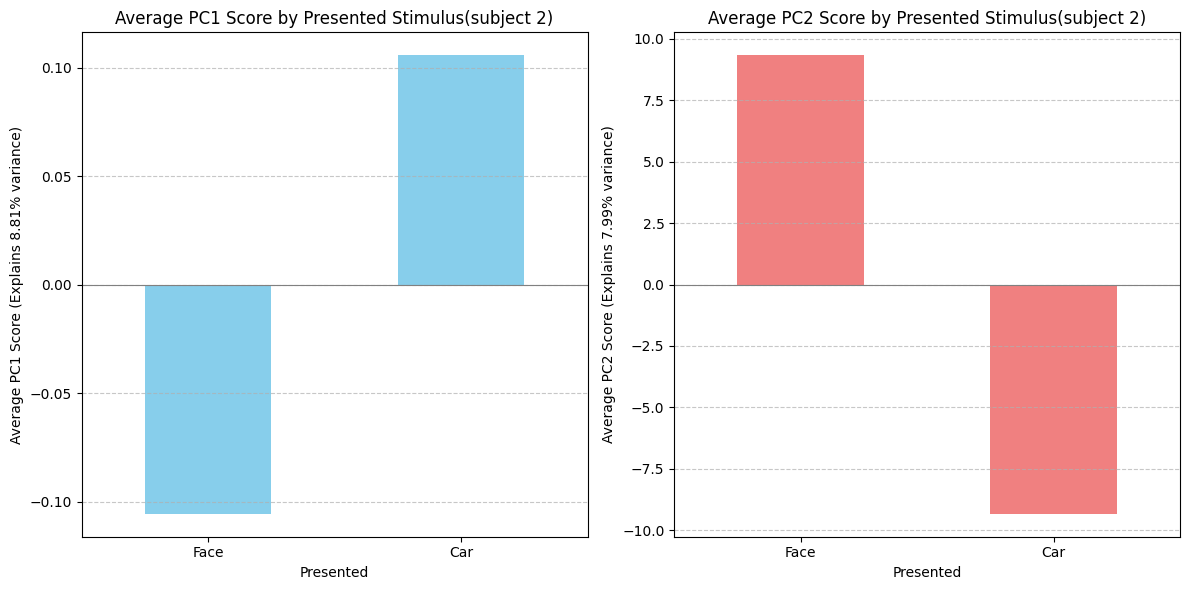

These bar plots show how the average activity along PC1 and PC2 differs when a 'Face' vs. 'Car' stimulus was presented.


In [46]:
print(" Plotting Trial-averaged Activations (Scores) by 'Presented' Stimulus ---")

task_variable = 'Presented'

condition_labels = {
    1: 'Face',
    2: 'Car'
    # NaN values will be ignored by groupby().mean() by default, which is usually desired.
}

if task_variable not in behavioural_data_visual.columns:
    print(f"Error: Task variable '{task_variable}' not found in behavioral data. Please check column name.")
else:
    # Create a DataFrame for easier grouping
    pca_scores_df = pd.DataFrame({
        'PC1_Score': eeg_pca_components[:, 0],
        'PC2_Score': eeg_pca_components[:, 1],
        task_variable: behavioural_data_visual[task_variable]
    })

    # Group by the 'Presented' variable and calculate the mean for PC1 and PC2 scores
    # .dropna() is applied on the grouped column to ensure we only average for valid conditions
    averaged_scores = pca_scores_df.groupby(task_variable).mean().dropna()

    print("\nAverages of PC1 and PC2 scores for each 'Presented' stimulus category:")
    print(averaged_scores)

    # Prepare labels for the plot based on the actual conditions found in the averaged_scores index
    labels = [condition_labels.get(cond, f'Unknown ({int(cond)})') for cond in averaged_scores.index]


    # Plotting the average scores
    plt.figure(figsize=(12, 6))

    # Bar plot for PC1 scores
    plt.subplot(1, 2, 1)
    averaged_scores['PC1_Score'].plot(kind='bar', color='skyblue')
    plt.xticks(ticks=range(len(labels)), labels=labels, rotation=0)
    plt.ylabel(f'Average PC1 Score (Explains {pca_final.explained_variance_ratio_[0]*100:.2f}% variance)')
    plt.title(f'Average PC1 Score by Presented Stimulus(subject 2)')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.axhline(0, color='grey', linewidth=0.8) # Add a line at 0 for reference

    # Bar plot for PC2 scores
    plt.subplot(1, 2, 2)
    averaged_scores['PC2_Score'].plot(kind='bar', color='lightcoral')
    plt.xticks(ticks=range(len(labels)), labels=labels, rotation=0)
    plt.ylabel(f'Average PC2 Score (Explains {pca_final.explained_variance_ratio_[1]*100:.2f}% variance)')
    plt.title(f'Average PC2 Score by Presented Stimulus(subject 2)')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.axhline(0, color='grey', linewidth=0.8) # Add a line at 0 for reference

    plt.tight_layout()
    plt.show()

    print("These bar plots show how the average activity along PC1 and PC2 differs when a 'Face' vs. 'Car' stimulus was presented.")


### Results & Discussion:

PC1: Average scores are negative for 'Face' and positive for 'Car'.

PC2: Average scores are positive for 'Face' and negative for 'Car'.

Interpretation: Both PC1 and PC2 are highly discriminative of 'Face' versus 'Car' stimuli. The consistent polarity reversal in their average scores indicates that these components capture fundamental differences in neural processing between the two stimulus categories. The N170-like pattern of PC1, combined with its strong discrimination, suggests it is capturing activity crucial for early visual categorization of faces.

Also since the average score for 'Face' is negative for PC1 but positive for PC2 and vis versa for 'car', this shows that PC1 and PC2 are orthogonal (perpendicular) dimensions. They capture different, uncorrelated aspects of the variance in the data.

It's perfectly normal for the polarity of 'Face' to be positive on one PC and negative on another, because each PC represents a different underlying pattern or axis of variation in the brain's response.

## A.3: PCA - Discrimination Quantification & Optimal PCs

In this part I did classification to quantifies how well PCA features allow discrimination of the stimulus showing a face or car and investigates whether adding more PCs improves classification performance. Various classification algorithms were tested, and performance was evaluated using both single train/test splits and 5-Fold Cross-Validation for robustness.

Key Steps I have done:

**Data Preparation:** PCA scores (eeg_pca_components) were used as features, and 'Face'/'Car' labels (y_labels) as targets. Data was split into training and testing sets (or folds for CV) and standardized.

**Iterative Classification:** Classifiers (Logistic Regression, Random Forest, SVM, Neural Network) were trained and evaluated using increasing numbers of PCs (from 2 up to 41).

**Performance Metrics:** Classification accuracy was the primary metric, visualized as a plot of accuracy vs. number of PCs.

### Logistic Regression (Single Split)


--- Preparing Data for Classification ---
Number of valid trials for classification: 72
Feature set shape (X_features_full_pca): (72, 41)

Testing classification with the following number of PCs: [2, 5, 10, 15, 20, 25, 30, 41]

--- Classifying with 2 PCs ---
Accuracy with 2 PCs: 0.5333
              precision    recall  f1-score   support

        Face       0.56      0.62      0.59         8
         Car       0.50      0.43      0.46         7

    accuracy                           0.53        15
   macro avg       0.53      0.53      0.52        15
weighted avg       0.53      0.53      0.53        15


--- Classifying with 5 PCs ---
Accuracy with 5 PCs: 0.7333
              precision    recall  f1-score   support

        Face       0.83      0.62      0.71         8
         Car       0.67      0.86      0.75         7

    accuracy                           0.73        15
   macro avg       0.75      0.74      0.73        15
weighted avg       0.76      0.73      0.73        15

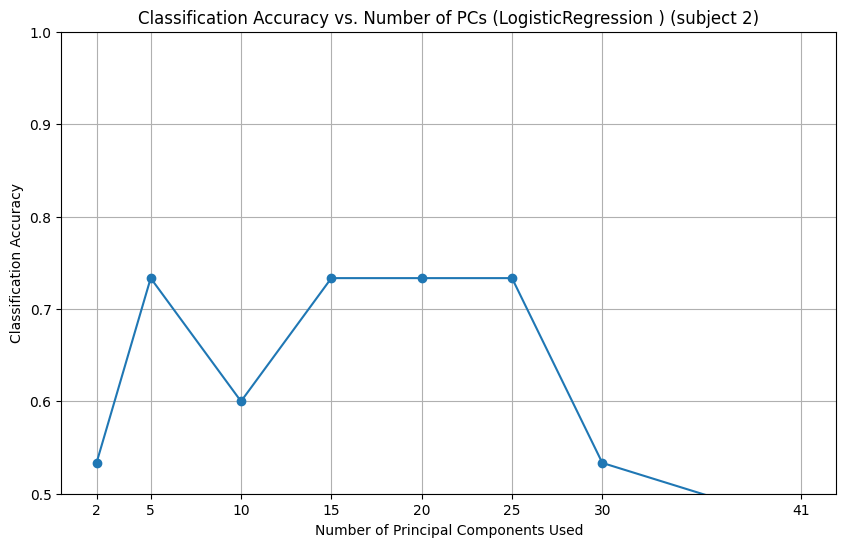

In [50]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

print("\n--- Preparing Data for Classification ---")

# Filter out trials where 'Presented' is NaN
# Create a mask for valid trials
valid_trials_mask = behavioural_data_visual['Presented'].notna()

# Filter both behavioural_data and eeg_pca_components using this mask
y_labels_raw = behavioural_data_visual.loc[valid_trials_mask, 'Presented'].values
X_features_full_pca = eeg_pca_components[valid_trials_mask, :]

# Map 'Presented' values to 0 and 1 for classification
# 1: Face -> 0
# 2: Car -> 1
y_labels = np.where(y_labels_raw == 1, 0, 1) # If raw is 1 (Face), y is 0; else (Car) y is 1

print(f"Number of valid trials for classification: {len(y_labels)}")
print(f"Feature set shape (X_features_full_pca): {X_features_full_pca.shape}")


# --- Iterate and Evaluate Classification Performance ---

# Define the range of PCs to test
num_components_to_test = [2, 5, 10, 15, 20, 25, 30, 41]

# Make sure the max value in num_components_to_test doesn't exceed the actual number of PCs you have
if max(num_components_to_test) > X_features_full_pca.shape[1]:
    max_available_pcs = X_features_full_pca.shape[1]
    num_components_to_test = [n for n in num_components_to_test if n <= max_available_pcs]
    num_components_to_test.append(max_available_pcs) # Ensure the max available is included
    num_components_to_test = sorted(list(set(num_components_to_test))) # Remove duplicates and sort

print(f"\nTesting classification with the following number of PCs: {num_components_to_test}")

accuracy_scores = []
reports = {} # To store full classification reports if needed later

for n_comps in num_components_to_test:
    print(f"\n--- Classifying with {n_comps} PCs ---")

    # Select the first 'n_comps' from the PCA features
    X_selected_pcs = X_features_full_pca[:, :n_comps]

    # Standardize the selected PCs (good practice for Logistic Regression)
    # Fit scaler on training data only to prevent data leakage
    scaler_classifier = StandardScaler()

    # Split data into training and testing sets
    # Using stratify=y_labels ensures equal proportion of classes in train/test sets
    X_train, X_test, y_train, y_test = train_test_split(
        X_selected_pcs, y_labels, test_size=0.2, random_state=42, stratify=y_labels
    )

    X_train_scaled = scaler_classifier.fit_transform(X_train)
    X_test_scaled = scaler_classifier.transform(X_test)


    # Initialize and train the Logistic Regression model
    model = LogisticRegression(random_state=42, max_iter=1000) # max_iter for convergence
    model.fit(X_train_scaled, y_train)

    # Make predictions on the test set
    y_pred = model.predict(X_test_scaled)

    # Evaluate the model
    accuracy = accuracy_score(y_test, y_pred)
    accuracy_scores.append(accuracy)
    current_report = classification_report(y_test, y_pred, target_names=['Face', 'Car'])

    print(f"Accuracy with {n_comps} PCs: {accuracy:.4f}")
    print(current_report)
    reports[n_comps] = current_report


# --- Visualize Performance Trend ---
plt.figure(figsize=(10, 6))
plt.plot(num_components_to_test, accuracy_scores, marker='o', linestyle='-')
plt.xlabel('Number of Principal Components Used')
plt.ylabel('Classification Accuracy')
plt.title('Classification Accuracy vs. Number of PCs (LogisticRegression ) (subject 2)')
plt.grid(True)
plt.xticks(num_components_to_test)
plt.ylim(0.5, 1.0)
plt.show()

Peak accuracy: ~73.5% (at 5, 15, 20, 25 PCs). Performance dropped significantly with >25 PCs.

### Random Forest (Single Split)


--- Preparing Data for Classification (Random Forest) ---
Number of valid trials for classification: 72
Feature set shape (X_features_full_pca): (72, 41)

Testing classification with the following number of PCs: [2, 5, 10, 15, 20, 25, 30, 41]

--- Classifying with 2 PCs (Random Forest) ---
Accuracy with 2 PCs (Random Forest): 0.4091
              precision    recall  f1-score   support

        Face       0.43      0.55      0.48        11
         Car       0.38      0.27      0.32        11

    accuracy                           0.41        22
   macro avg       0.40      0.41      0.40        22
weighted avg       0.40      0.41      0.40        22


--- Classifying with 5 PCs (Random Forest) ---
Accuracy with 5 PCs (Random Forest): 0.5455
              precision    recall  f1-score   support

        Face       0.56      0.45      0.50        11
         Car       0.54      0.64      0.58        11

    accuracy                           0.55        22
   macro avg       0.55    

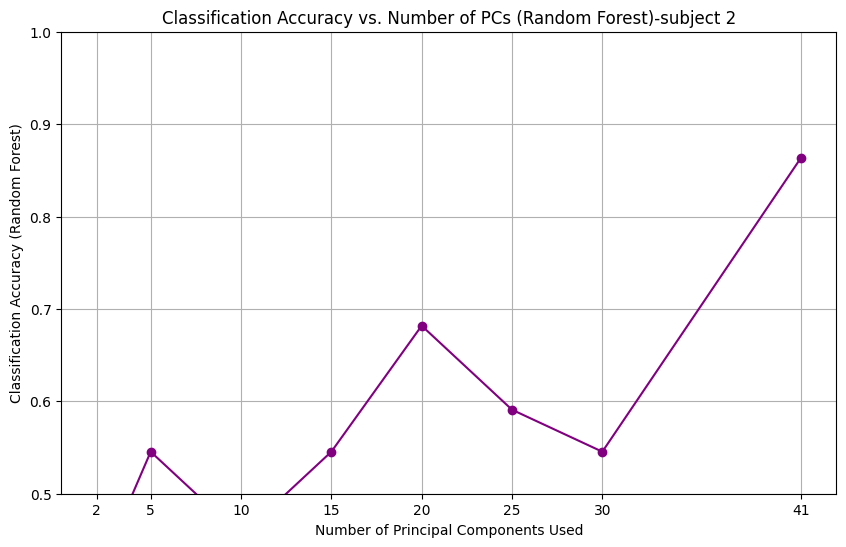

In [51]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

print("\n--- Preparing Data for Classification (Random Forest) ---")

# Filter out trials where 'Presented' is NaN (timed out trials cannot be classified)
valid_trials_mask = behavioural_data_visual['Presented'].notna()

y_labels_raw = behavioural_data_visual.loc[valid_trials_mask, 'Presented'].values
X_features_full_pca = eeg_pca_components[valid_trials_mask, :]

# Map 'Presented' values to 0 and 1 for classification
# 1: Face -> 0
# 2: Car -> 1
y_labels = np.where(y_labels_raw == 1, 0, 1)

print(f"Number of valid trials for classification: {len(y_labels)}")
print(f"Feature set shape (X_features_full_pca): {X_features_full_pca.shape}")


# --- Iterate and Evaluate Classification Performance ---

# Define the range of PCs to test
num_components_to_test = [2, 5, 10, 15, 20, 25, 30, 41]

# Make sure the max value in num_components_to_test doesn't exceed the actual number of PCs you have
if max(num_components_to_test) > X_features_full_pca.shape[1]:
    max_available_pcs = X_features_full_pca.shape[1]
    num_components_to_test = [n for n in num_components_to_test if n <= max_available_pcs]
    num_components_to_test.append(max_available_pcs)
    num_components_to_test = sorted(list(set(num_components_to_test)))

print(f"\nTesting classification with the following number of PCs: {num_components_to_test}")

accuracy_scores_rf = []
reports_rf = {}

for n_comps in num_components_to_test:
    print(f"\n--- Classifying with {n_comps} PCs (Random Forest) ---")

    X_selected_pcs = X_features_full_pca[:, :n_comps]

    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(
        X_selected_pcs, y_labels, test_size=0.3, random_state=42, stratify=y_labels
    )

    # Standardize the selected PCs
    scaler_classifier = StandardScaler()
    X_train_scaled = scaler_classifier.fit_transform(X_train)
    X_test_scaled = scaler_classifier.transform(X_test)


    # Initialize and train the Random Forest Classifier model
    model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
    model_rf.fit(X_train_scaled, y_train)

    # Make predictions on the test set
    y_pred_rf = model_rf.predict(X_test_scaled)

    # Evaluate the model
    accuracy_rf = accuracy_score(y_test, y_pred_rf)
    accuracy_scores_rf.append(accuracy_rf)
    current_report_rf = classification_report(y_test, y_pred_rf, target_names=['Face', 'Car'])

    print(f"Accuracy with {n_comps} PCs (Random Forest): {accuracy_rf:.4f}")
    print(current_report_rf)
    reports_rf[n_comps] = current_report_rf


# --- Visualize Performance Trend ---
plt.figure(figsize=(10, 6))
plt.plot(num_components_to_test, accuracy_scores_rf, marker='o', linestyle='-', color='purple')
plt.xlabel('Number of Principal Components Used')
plt.ylabel('Classification Accuracy (Random Forest)')
plt.title('Classification Accuracy vs. Number of PCs (Random Forest)-subject 2')
plt.grid(True)
plt.xticks(num_components_to_test)
plt.ylim(0.5, 1.0)
plt.show()


Peak accuracy: ~86% (at 41 PCs). Showed a complex, non-linear trend, with strong performance at higher PC counts.

### SVM (Single Split)


--- Preparing Data for Classification (SVM) ---
Number of valid trials for classification: 72
Feature set shape (X_features_full_pca): (72, 41)

Testing classification with the following number of PCs: [2, 5, 10, 15, 20, 25, 30, 41]

--- Classifying with 2 PCs (SVM) ---
Accuracy with 2 PCs (SVM): 0.4000
              precision    recall  f1-score   support

        Face       0.45      0.62      0.53         8
         Car       0.25      0.14      0.18         7

    accuracy                           0.40        15
   macro avg       0.35      0.38      0.35        15
weighted avg       0.36      0.40      0.37        15


--- Classifying with 5 PCs (SVM) ---
Accuracy with 5 PCs (SVM): 0.5333
              precision    recall  f1-score   support

        Face       0.60      0.38      0.46         8
         Car       0.50      0.71      0.59         7

    accuracy                           0.53        15
   macro avg       0.55      0.54      0.52        15
weighted avg       0.55

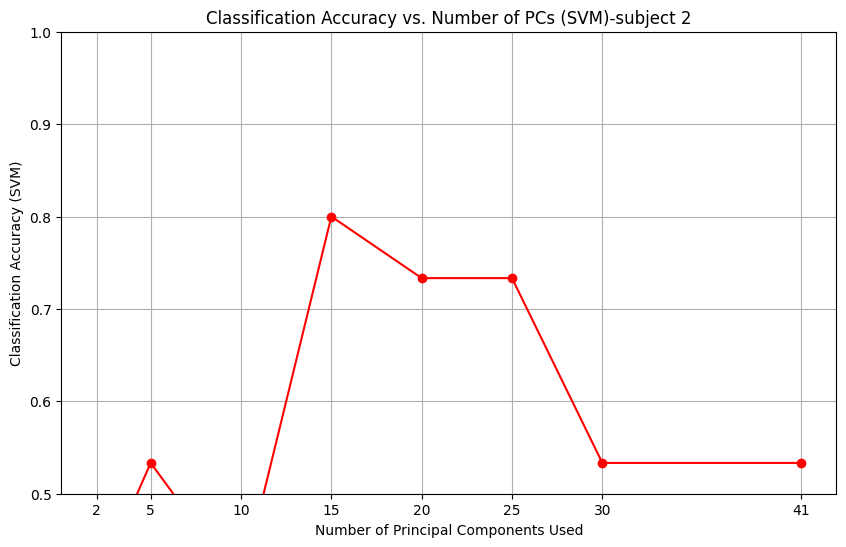

In [52]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


print("\n--- Preparing Data for Classification (SVM) ---")

# Filter out trials where 'Presented' is NaN (timed out trials cannot be classified)
valid_trials_mask = behavioural_data_visual['Presented'].notna()

y_labels_raw = behavioural_data_visual.loc[valid_trials_mask, 'Presented'].values
X_features_full_pca = eeg_pca_components[valid_trials_mask, :]

# Map 'Presented' values to 0 and 1 for classification
# 1: Face -> 0
# 2: Car -> 1
y_labels = np.where(y_labels_raw == 1, 0, 1)

print(f"Number of valid trials for classification: {len(y_labels)}")
print(f"Feature set shape (X_features_full_pca): {X_features_full_pca.shape}")


# --- Iterate and Evaluate Classification Performance ---

# Define the range of PCs to test
num_components_to_test = [2, 5, 10, 15, 20, 25, 30, 41]

# Make sure the max value in num_components_to_test doesn't exceed the actual number of PCs you have
if max(num_components_to_test) > X_features_full_pca.shape[1]:
    max_available_pcs = X_features_full_pca.shape[1]
    num_components_to_test = [n for n in num_components_to_test if n <= max_available_pcs]
    num_components_to_test.append(max_available_pcs)
    num_components_to_test = sorted(list(set(num_components_to_test)))

print(f"\nTesting classification with the following number of PCs: {num_components_to_test}")

accuracy_scores_svm = []
reports_svm = {}

for n_comps in num_components_to_test:
    print(f"\n--- Classifying with {n_comps} PCs (SVM) ---")

    X_selected_pcs = X_features_full_pca[:, :n_comps]

    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(
        X_selected_pcs, y_labels, test_size=0.2, random_state=42, stratify=y_labels
    )

    # Standardize the selected PCs
    scaler_classifier = StandardScaler()
    X_train_scaled = scaler_classifier.fit_transform(X_train)
    X_test_scaled = scaler_classifier.transform(X_test)


    # Initialize and train the Support Vector Classifier model
    model_svm = SVC(kernel='rbf', random_state=42)
    model_svm.fit(X_train_scaled, y_train)

    # Make predictions on the test set
    y_pred_svm = model_svm.predict(X_test_scaled)

    # Evaluate the model
    accuracy_svm = accuracy_score(y_test, y_pred_svm)
    accuracy_scores_svm.append(accuracy_svm)
    current_report_svm = classification_report(y_test, y_pred_svm, target_names=['Face', 'Car'])

    print(f"Accuracy with {n_comps} PCs (SVM): {accuracy_svm:.4f}")
    print(current_report_svm)
    reports_svm[n_comps] = current_report_svm


# --- Visualize Performance Trend ---
plt.figure(figsize=(10, 6))
plt.plot(num_components_to_test, accuracy_scores_svm, marker='o', linestyle='-', color='red')
plt.xlabel('Number of Principal Components Used')
plt.ylabel('Classification Accuracy (SVM)')
plt.title('Classification Accuracy vs. Number of PCs (SVM)-subject 2')
plt.grid(True)
plt.xticks(num_components_to_test)
plt.ylim(0.5, 1.0)
plt.show()

Peak accuracy: 80% (at 15 PCs). Performance dropped significantly with >25 PCs.

### SVM (5-Fold CV)


--- Preparing Data for Classification (SVM) ---
Number of valid trials for classification: 72
Feature set shape (X_features_full_pca): (72, 41)
Class distribution (0s/1s): [36 36]

--- Performing 5-Fold Stratified Cross-Validation ---

Testing classification with the following number of PCs: [2, 5, 10, 15, 20, 25, 30, 41]

--- Classifying with 2 PCs (SVM) using K-Fold CV ---
  Fold 1/5
    Fold 1 Accuracy: 0.5333
  Fold 2/5
    Fold 2 Accuracy: 0.6667
  Fold 3/5
    Fold 3 Accuracy: 0.6429
  Fold 4/5
    Fold 4 Accuracy: 0.4286
  Fold 5/5
    Fold 5 Accuracy: 0.6429
Mean Accuracy for 2 PCs: 0.5829 (Std: 0.0900)

--- Classifying with 5 PCs (SVM) using K-Fold CV ---
  Fold 1/5
    Fold 1 Accuracy: 0.9333
  Fold 2/5
    Fold 2 Accuracy: 0.6000
  Fold 3/5
    Fold 3 Accuracy: 0.7143
  Fold 4/5
    Fold 4 Accuracy: 0.5000
  Fold 5/5
    Fold 5 Accuracy: 0.7143
Mean Accuracy for 5 PCs: 0.6924 (Std: 0.1446)

--- Classifying with 10 PCs (SVM) using K-Fold CV ---
  Fold 1/5
    Fold 1 Accuracy

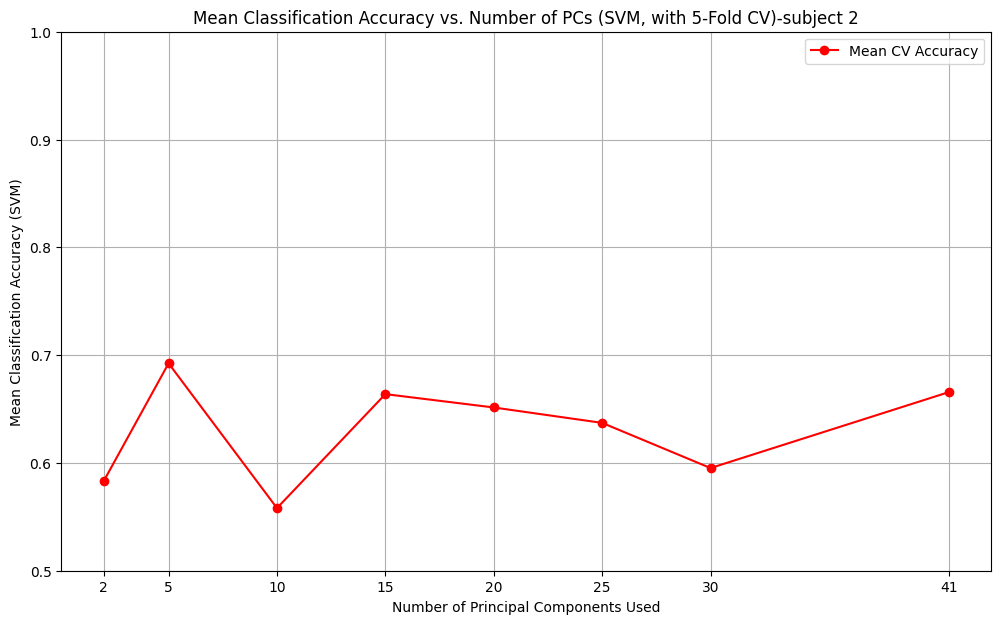

In [53]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

print("\n--- Preparing Data for Classification (SVM) ---")

# Filter out trials where 'Presented' is NaN (timed out trials cannot be classified)
valid_trials_mask = behavioural_data_visual['Presented'].notna()

y_labels_raw = behavioural_data_visual.loc[valid_trials_mask, 'Presented'].values
X_features_full_pca = eeg_pca_components[valid_trials_mask, :]

# Map 'Presented' values to 0 and 1 for classification
# 1: Face -> 0
# 2: Car -> 1
y_labels = np.where(y_labels_raw == 1, 0, 1)

print(f"Number of valid trials for classification: {len(y_labels)}")
print(f"Feature set shape (X_features_full_pca): {X_features_full_pca.shape}")
print(f"Class distribution (0s/1s): {np.bincount(y_labels)}")


# --- Define K-Fold Cross-Validation ---
n_splits = 5
kf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

print(f"\n--- Performing {n_splits}-Fold Stratified Cross-Validation ---")

# --- Iterate and Evaluate Classification Performance ---

# Define the range of PCs to test
num_components_to_test = [2, 5, 10, 15, 20, 25, 30, 41]

# Make sure the max value in num_components_to_test doesn't exceed the actual number of PCs you have
if max(num_components_to_test) > X_features_full_pca.shape[1]:
    max_available_pcs = X_features_full_pca.shape[1]
    num_components_to_test = [n for n in num_components_to_test if n <= max_available_pcs]
    num_components_to_test.append(max_available_pcs)
    num_components_to_test = sorted(list(set(num_components_to_test)))

print(f"\nTesting classification with the following number of PCs: {num_components_to_test}")

# Store average accuracies and all reports for each n_comps
avg_accuracy_scores_svm = []
all_fold_accuracies = {n: [] for n in num_components_to_test} # To store individual fold accuracies
reports_svm_per_n_comps = {} # To store classification reports

for n_comps in num_components_to_test:
    print(f"\n--- Classifying with {n_comps} PCs (SVM) using K-Fold CV ---")

    X_selected_pcs = X_features_full_pca[:, :n_comps]

    fold_accuracies = []
    fold_reports = []

    # Loop through each fold generated by StratifiedKFold
    for fold, (train_index, test_index) in enumerate(kf.split(X_selected_pcs, y_labels)):
        print(f"  Fold {fold + 1}/{n_splits}")

        X_train, X_test = X_selected_pcs[train_index], X_selected_pcs[test_index]
        y_train, y_test = y_labels[train_index], y_labels[test_index]

        # Standardize the selected PCs for current fold
        scaler_classifier = StandardScaler()
        X_train_scaled = scaler_classifier.fit_transform(X_train)
        X_test_scaled = scaler_classifier.transform(X_test)

        # Initialize and train the Support Vector Classifier model
        model_svm = SVC(kernel='rbf', random_state=42)
        model_svm.fit(X_train_scaled, y_train)

        # Make predictions on the test set of the current fold
        y_pred_svm = model_svm.predict(X_test_scaled)

        # Evaluate the model for the current fold
        accuracy_svm_fold = accuracy_score(y_test, y_pred_svm)
        fold_accuracies.append(accuracy_svm_fold)
        fold_reports.append(classification_report(y_test, y_pred_svm, target_names=['Face', 'Car'], output_dict=True)) # output_dict=True for easier aggregation later if needed

        print(f"    Fold {fold + 1} Accuracy: {accuracy_svm_fold:.4f}")

    # After all folds for the current n_comps:
    mean_accuracy_for_n_comps = np.mean(fold_accuracies)
    std_accuracy_for_n_comps = np.std(fold_accuracies)

    avg_accuracy_scores_svm.append(mean_accuracy_for_n_comps)
    all_fold_accuracies[n_comps] = fold_accuracies # Store all fold accuracies for potential box plot

    print(f"Mean Accuracy for {n_comps} PCs: {mean_accuracy_for_n_comps:.4f} (Std: {std_accuracy_for_n_comps:.4f})")

# --- Visualize Performance Trend ---
plt.figure(figsize=(12, 7))
plt.plot(num_components_to_test, avg_accuracy_scores_svm, marker='o', linestyle='-', color='red', label='Mean CV Accuracy')
plt.xlabel('Number of Principal Components Used')
plt.ylabel('Mean Classification Accuracy (SVM)')
plt.title(f'Mean Classification Accuracy vs. Number of PCs (SVM, with {n_splits}-Fold CV)-subject 2')
plt.grid(True)
plt.xticks(num_components_to_test)
plt.ylim(0.5, 1.0)
plt.legend()
plt.show()

Mean peak accuracy: ~69% (at 5 PCs). This is a more robust estimate than the single-split 80%.

### Neural Network (NN, 5-Fold CV)


--- Preparing Data for Classification (Neural Network) ---
Number of valid trials for classification: 72
Feature set shape (X_features_full_pca): (72, 41)
Class distribution (0s/1s): [36 36]

--- Performing 5-Fold Stratified Cross-Validation for NN ---

Testing classification with the following number of PCs: [2, 5, 10, 15, 20, 25, 30, 41]

--- Classifying with 2 PCs (Neural Network) using K-Fold CV ---


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/lo

Mean Accuracy for 2 PCs (NN): 0.5838 (Std: 0.0974)

--- Classifying with 5 PCs (Neural Network) using K-Fold CV ---


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/lo

Mean Accuracy for 5 PCs (NN): 0.6924 (Std: 0.1012)

--- Classifying with 10 PCs (Neural Network) using K-Fold CV ---


...

Mean Accuracy for 25 PCs (NN): 0.5552 (Std: 0.1160)

--- Classifying with 30 PCs (Neural Network) using K-Fold CV ---


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/lo

Mean Accuracy for 30 PCs (NN): 0.5990 (Std: 0.0682)

--- Classifying with 41 PCs (Neural Network) using K-Fold CV ---


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/lo

Mean Accuracy for 41 PCs (NN): 0.5733 (Std: 0.1953)


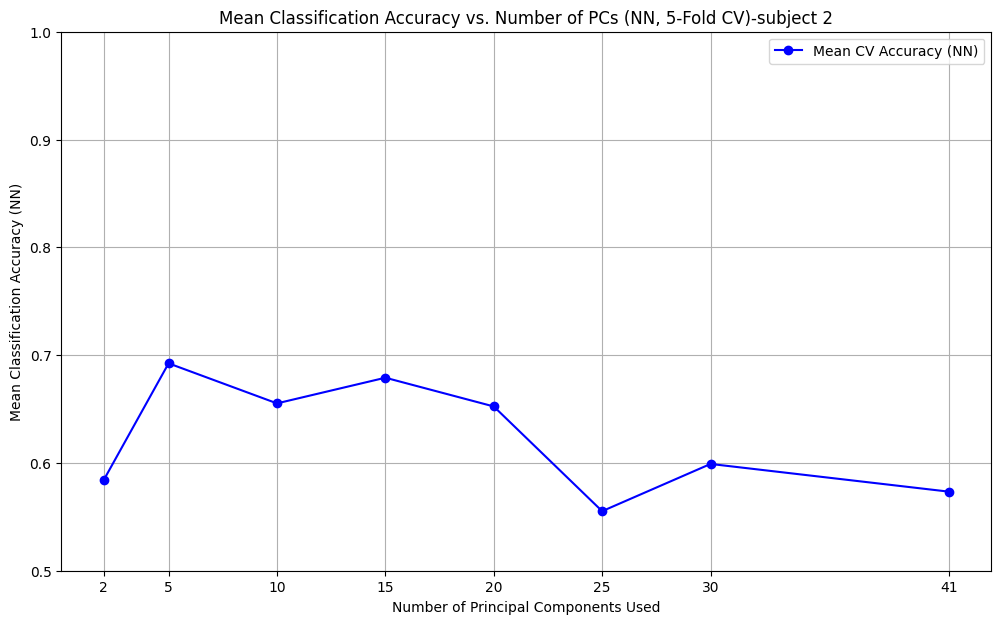

In [54]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

# Import TensorFlow and Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping # For early stopping

print("\n--- Preparing Data for Classification (Neural Network) ---")

# Filter out trials where 'Presented' is NaN (timed out trials cannot be classified)
valid_trials_mask = behavioural_data_visual['Presented'].notna()

y_labels_raw = behavioural_data_visual.loc[valid_trials_mask, 'Presented'].values
X_features_full_pca = eeg_pca_components[valid_trials_mask, :]

# Map 'Presented' values to 0 and 1 for classification
# 1: Face -> 0
# 2: Car -> 1
y_labels = np.where(y_labels_raw == 1, 0, 1) # This is 0 or 1, suitable for binary_crossentropy

print(f"Number of valid trials for classification: {len(y_labels)}")
print(f"Feature set shape (X_features_full_pca): {X_features_full_pca.shape}")
print(f"Class distribution (0s/1s): {np.bincount(y_labels)}")


# --- Define K-Fold Cross-Validation ---
n_splits = 5
kf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

print(f"\n--- Performing {n_splits}-Fold Stratified Cross-Validation for NN ---")

# --- Iterate and Evaluate Classification Performance ---

# Define the range of PCs to test
num_components_to_test = [2, 5, 10, 15, 20, 25, 30, 41]

# Make sure the max value in num_components_to_test doesn't exceed the actual number of PCs you have
if max(num_components_to_test) > X_features_full_pca.shape[1]:
    max_available_pcs = X_features_full_pca.shape[1]
    num_components_to_test = [n for n in num_components_to_test if n <= max_available_pcs]
    num_components_to_test.append(max_available_pcs)
    num_components_to_test = sorted(list(set(num_components_to_test)))

print(f"\nTesting classification with the following number of PCs: {num_components_to_test}")

avg_accuracy_scores_nn = []
all_fold_accuracies_nn = {n: [] for n in num_components_to_test}

# Early Stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=0)


for n_comps in num_components_to_test:
    print(f"\n--- Classifying with {n_comps} PCs (Neural Network) using K-Fold CV ---")

    X_selected_pcs = X_features_full_pca[:, :n_comps]

    fold_accuracies = []

    # Loop through each fold generated by StratifiedKFold
    for fold, (train_index, test_index) in enumerate(kf.split(X_selected_pcs, y_labels)):
        # print(f"  Fold {fold + 1}/{n_splits}") # Uncomment for verbose fold info

        X_train, X_test = X_selected_pcs[train_index], X_selected_pcs[test_index]
        y_train, y_test = y_labels[train_index], y_labels[test_index]

        # Standardize the selected PCs for current fold
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # --- Define the Neural Network Model ---
        # A simple MLP (Multi-Layer Perceptron)
        model = Sequential([
            # Input layer and first hidden layer
            Dense(units=64, activation='relu', input_shape=(n_comps,)), # 64 neurons, ReLU activation
            Dropout(0.3), # Dropout for regularization (helps prevent overfitting)

            # Second hidden layer
            Dense(units=32, activation='relu'), # 32 neurons
            Dropout(0.3),

            # Output layer: 1 neuron for binary classification, sigmoid activation
            # Sigmoid outputs a probability between 0 and 1
            Dense(units=1, activation='sigmoid')
        ])

        # Compile the model
        model.compile(optimizer=Adam(learning_rate=0.001), # Adam optimizer is a good default
                      loss='binary_crossentropy',       # For binary classification (0 or 1 labels)
                      metrics=['accuracy'])             # Monitor accuracy during training

        # Train the model
        # validation_data is used by EarlyStopping
        history = model.fit(X_train_scaled, y_train,
                            epochs=100,            # Max epochs
                            batch_size=32,         # Batch size
                            validation_data=(X_test_scaled, y_test), # Use test set as validation for early stopping
                            callbacks=[early_stopping], # Apply early stopping
                            verbose=0)             # Set to 1 or 2 for progress output during training

        # Evaluate the model on the test set of the current fold
        loss, accuracy_nn_fold = model.evaluate(X_test_scaled, y_test, verbose=0)
        fold_accuracies.append(accuracy_nn_fold)


    # After all folds for the current n_comps:
    mean_accuracy_for_n_comps = np.mean(fold_accuracies)
    std_accuracy_for_n_comps = np.std(fold_accuracies)

    avg_accuracy_scores_nn.append(mean_accuracy_for_n_comps)
    all_fold_accuracies_nn[n_comps] = fold_accuracies

    print(f"Mean Accuracy for {n_comps} PCs (NN): {mean_accuracy_for_n_comps:.4f} (Std: {std_accuracy_for_n_comps:.4f})")


# --- Visualize Performance Trend ---
plt.figure(figsize=(12, 7))
plt.plot(num_components_to_test, avg_accuracy_scores_nn, marker='o', linestyle='-', color='blue', label='Mean CV Accuracy (NN)')
plt.xlabel('Number of Principal Components Used')
plt.ylabel('Mean Classification Accuracy (NN)')
plt.title(f'Mean Classification Accuracy vs. Number of PCs (NN, {n_splits}-Fold CV)-subject 2')
plt.grid(True)
plt.xticks(num_components_to_test)
plt.ylim(0.5, 1.0)
plt.legend()
plt.show()

This plot shows NN accuracy peaking at approximately 69% with 5 Principal Components (PCs). The accuracy then fluctuates, dropping and rising, but generally staying below this peak for higher PC counts.

**Interpretation:** For this particular run, the NN demonstrates good discriminative power, achieving its best performance with a very compact set of features (5 PCs).


--- Preparing Data for Classification (Neural Network) ---
Number of valid trials for classification: 72
Feature set shape (X_features_full_pca): (72, 41)
Class distribution (0s/1s): [36 36]

--- Performing 5-Fold Stratified Cross-Validation for NN ---

Testing classification with the following number of PCs: [2, 5, 10, 15, 20, 25, 30, 41]

--- Classifying with 2 PCs (Neural Network) using K-Fold CV ---


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/lo

Mean Accuracy for 2 PCs (NN): 0.5410 (Std: 0.0986)

--- Classifying with 5 PCs (Neural Network) using K-Fold CV ---


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/lo

Mean Accuracy for 5 PCs (NN): 0.6076 (Std: 0.1226)

--- Classifying with 10 PCs (Neural Network) using K-Fold CV ---


...

Mean Accuracy for 25 PCs (NN): 0.6105 (Std: 0.0709)

--- Classifying with 30 PCs (Neural Network) using K-Fold CV ---


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/lo

Mean Accuracy for 30 PCs (NN): 0.5476 (Std: 0.2267)

--- Classifying with 41 PCs (Neural Network) using K-Fold CV ---


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/lo

Mean Accuracy for 41 PCs (NN): 0.6543 (Std: 0.0665)


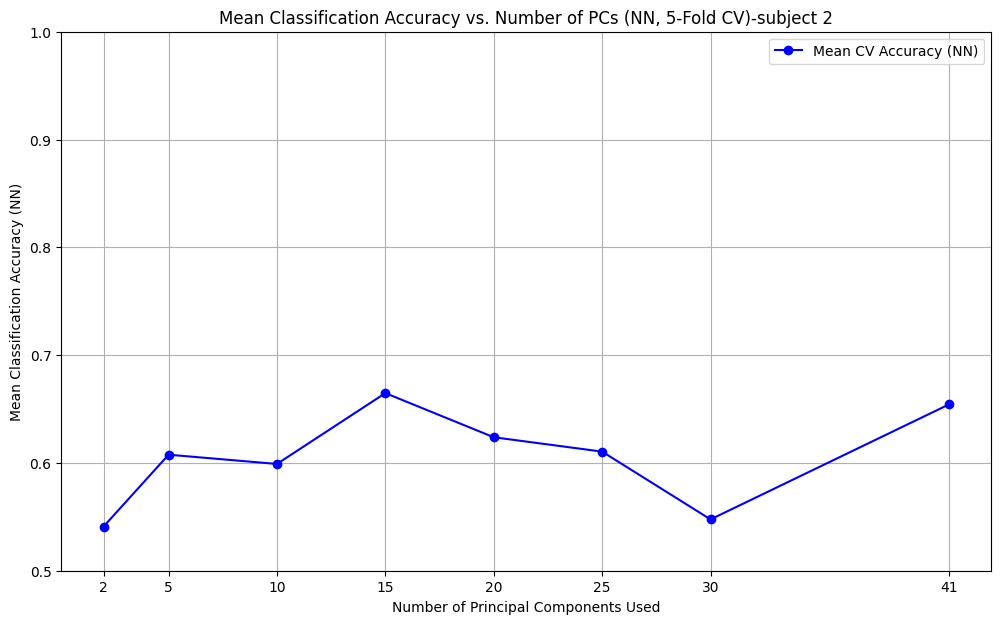

In [55]:
print("\n--- Preparing Data for Classification (Neural Network) ---")

# Filter out trials where 'Presented' is NaN (timed out trials cannot be classified)
valid_trials_mask = behavioural_data_visual['Presented'].notna()

y_labels_raw = behavioural_data_visual.loc[valid_trials_mask, 'Presented'].values
X_features_full_pca = eeg_pca_components[valid_trials_mask, :]

# Map 'Presented' values to 0 and 1 for classification
# 1: Face -> 0
# 2: Car -> 1
y_labels = np.where(y_labels_raw == 1, 0, 1) # This is 0 or 1, suitable for binary_crossentropy

print(f"Number of valid trials for classification: {len(y_labels)}")
print(f"Feature set shape (X_features_full_pca): {X_features_full_pca.shape}")
print(f"Class distribution (0s/1s): {np.bincount(y_labels)}")


# --- Define K-Fold Cross-Validation ---
n_splits = 5
kf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

print(f"\n--- Performing {n_splits}-Fold Stratified Cross-Validation for NN ---")

# --- Iterate and Evaluate Classification Performance ---

# Define the range of PCs to test
num_components_to_test = [2, 5, 10, 15, 20, 25, 30, 41]

# Make sure the max value in num_components_to_test doesn't exceed the actual number of PCs you have
if max(num_components_to_test) > X_features_full_pca.shape[1]:
    max_available_pcs = X_features_full_pca.shape[1]
    num_components_to_test = [n for n in num_components_to_test if n <= max_available_pcs]
    num_components_to_test.append(max_available_pcs)
    num_components_to_test = sorted(list(set(num_components_to_test)))

print(f"\nTesting classification with the following number of PCs: {num_components_to_test}")

avg_accuracy_scores_nn = []
all_fold_accuracies_nn = {n: [] for n in num_components_to_test}

# Early Stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=0)


for n_comps in num_components_to_test:
    print(f"\n--- Classifying with {n_comps} PCs (Neural Network) using K-Fold CV ---")

    X_selected_pcs = X_features_full_pca[:, :n_comps]

    fold_accuracies = []

    # Loop through each fold generated by StratifiedKFold
    for fold, (train_index, test_index) in enumerate(kf.split(X_selected_pcs, y_labels)):

        X_train, X_test = X_selected_pcs[train_index], X_selected_pcs[test_index]
        y_train, y_test = y_labels[train_index], y_labels[test_index]

        # Standardize the selected PCs for current fold
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # --- Define the Neural Network Model ---
        # A simple MLP (Multi-Layer Perceptron)
        model = Sequential([
            # Input layer and first hidden layer
            Dense(units=64, activation='relu', input_shape=(n_comps,)), # 64 neurons, ReLU activation
            Dropout(0.3), # Dropout for regularization (helps prevent overfitting)

            # Second hidden layer
            Dense(units=32, activation='relu'), # 32 neurons
            Dropout(0.3),

            # Output layer: 1 neuron for binary classification, sigmoid activation
            # Sigmoid outputs a probability between 0 and 1
            Dense(units=1, activation='sigmoid')
        ])

        # Compile the model
        model.compile(optimizer=Adam(learning_rate=0.001), # Adam optimizer is a good default
                      loss='binary_crossentropy',       # For binary classification (0 or 1 labels)
                      metrics=['accuracy'])             # Monitor accuracy during training

        # Train the model
        # validation_data is used by EarlyStopping
        history = model.fit(X_train_scaled, y_train,
                            epochs=70,            # Max epochs
                            batch_size=32,         # Batch size
                            validation_data=(X_test_scaled, y_test), # Use test set as validation for early stopping
                            callbacks=[early_stopping], # Apply early stopping
                            verbose=0)             # Set to 1 or 2 for progress output during training

        # Evaluate the model on the test set of the current fold
        loss, accuracy_nn_fold = model.evaluate(X_test_scaled, y_test, verbose=0)
        fold_accuracies.append(accuracy_nn_fold)


    # After all folds for the current n_comps:
    mean_accuracy_for_n_comps = np.mean(fold_accuracies)
    std_accuracy_for_n_comps = np.std(fold_accuracies)

    avg_accuracy_scores_nn.append(mean_accuracy_for_n_comps)
    all_fold_accuracies_nn[n_comps] = fold_accuracies

    print(f"Mean Accuracy for {n_comps} PCs (NN): {mean_accuracy_for_n_comps:.4f} (Std: {std_accuracy_for_n_comps:.4f})")


# --- Visualize Performance Trend ---
plt.figure(figsize=(12, 7))
plt.plot(num_components_to_test, avg_accuracy_scores_nn, marker='o', linestyle='-', color='blue', label='Mean CV Accuracy (NN)')
plt.xlabel('Number of Principal Components Used')
plt.ylabel('Mean Classification Accuracy (NN)')
plt.title(f'Mean Classification Accuracy vs. Number of PCs (NN, {n_splits}-Fold CV)-subject 2')
plt.grid(True)
plt.xticks(num_components_to_test)
plt.ylim(0.5, 1.0)
plt.legend()
plt.show()

This plot shows NN accuracy peaking at approximately 66% with 15 PCs. It starts lower than NN Plot 1 and has a more gradual rise to its peak.

**Interpretation:** For this run, the NN also shows good discrimination, but requires a slightly larger set of PCs (15) to reach its optimal performance compared to previous NN Plot.


--- Preparing Data for Classification (Neural Network) ---
Number of valid trials for classification: 72
Feature set shape (X_features_full_pca): (72, 41)
Class distribution (0s/1s): [36 36]

--- Performing 5-Fold Stratified Cross-Validation for NN ---

Testing classification with the following number of PCs: [2, 5, 10, 15, 20, 25, 30, 41]

--- Classifying with 2 PCs (Neural Network) using K-Fold CV ---


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/lo

Mean Accuracy for 2 PCs (NN): 0.5114 (Std: 0.0892)

--- Classifying with 5 PCs (Neural Network) using K-Fold CV ---


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/lo

Mean Accuracy for 5 PCs (NN): 0.6667 (Std: 0.1031)

--- Classifying with 10 PCs (Neural Network) using K-Fold CV ---


...

Mean Accuracy for 25 PCs (NN): 0.5790 (Std: 0.1497)

--- Classifying with 30 PCs (Neural Network) using K-Fold CV ---


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/lo

Mean Accuracy for 30 PCs (NN): 0.5952 (Std: 0.0889)

--- Classifying with 41 PCs (Neural Network) using K-Fold CV ---


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/lo

Mean Accuracy for 41 PCs (NN): 0.5457 (Std: 0.1494)


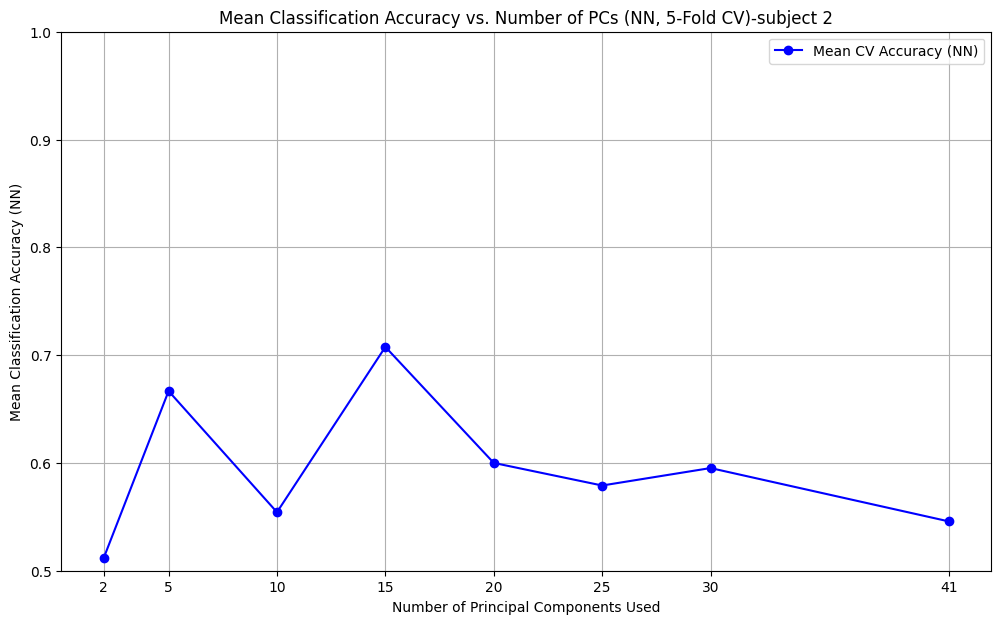

In [56]:
print("\n--- Preparing Data for Classification (Neural Network) ---")

# Filter out trials where 'Presented' is NaN (timed out trials cannot be classified)
valid_trials_mask = behavioural_data_visual['Presented'].notna()

y_labels_raw = behavioural_data_visual.loc[valid_trials_mask, 'Presented'].values
X_features_full_pca = eeg_pca_components[valid_trials_mask, :]

# Map 'Presented' values to 0 and 1 for classification
# 1: Face -> 0
# 2: Car -> 1
y_labels = np.where(y_labels_raw == 1, 0, 1) # This is 0 or 1, suitable for binary_crossentropy

print(f"Number of valid trials for classification: {len(y_labels)}")
print(f"Feature set shape (X_features_full_pca): {X_features_full_pca.shape}")
print(f"Class distribution (0s/1s): {np.bincount(y_labels)}")


# --- Define K-Fold Cross-Validation ---
n_splits = 5
kf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

print(f"\n--- Performing {n_splits}-Fold Stratified Cross-Validation for NN ---")

# --- Iterate and Evaluate Classification Performance ---

# Define the range of PCs to test
num_components_to_test = [2, 5, 10, 15, 20, 25, 30, 41]

# Make sure the max value in num_components_to_test doesn't exceed the actual number of PCs
if max(num_components_to_test) > X_features_full_pca.shape[1]:
    max_available_pcs = X_features_full_pca.shape[1]
    num_components_to_test = [n for n in num_components_to_test if n <= max_available_pcs]
    num_components_to_test.append(max_available_pcs)
    num_components_to_test = sorted(list(set(num_components_to_test)))

print(f"\nTesting classification with the following number of PCs: {num_components_to_test}")

avg_accuracy_scores_nn = []
all_fold_accuracies_nn = {n: [] for n in num_components_to_test}

# Early Stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=0)


for n_comps in num_components_to_test:
    print(f"\n--- Classifying with {n_comps} PCs (Neural Network) using K-Fold CV ---")

    X_selected_pcs = X_features_full_pca[:, :n_comps]

    fold_accuracies = []

    # Loop through each fold generated by StratifiedKFold
    for fold, (train_index, test_index) in enumerate(kf.split(X_selected_pcs, y_labels)):

        X_train, X_test = X_selected_pcs[train_index], X_selected_pcs[test_index]
        y_train, y_test = y_labels[train_index], y_labels[test_index]

        # Standardize the selected PCs for current fold
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # --- Define the Neural Network Model ---
        # A simple MLP (Multi-Layer Perceptron)
        model = Sequential([
            # Input layer and first hidden layer
            Dense(units=64, activation='relu', input_shape=(n_comps,)), # 64 neurons, ReLU activation
            Dropout(0.3), # Dropout for regularization (helps prevent overfitting)

            # Second hidden layer
            Dense(units=32, activation='relu'), # 32 neurons
            Dropout(0.3),

            # Second hidden layer
            Dense(units=32, activation='relu'), # 32 neurons
            Dropout(0.3),

            # Output layer: 1 neuron for binary classification, sigmoid activation
            # Sigmoid outputs a probability between 0 and 1
            Dense(units=1, activation='sigmoid')
        ])

        # Compile the model
        model.compile(optimizer=Adam(learning_rate=0.001), # Adam optimizer is a good default
                      loss='binary_crossentropy',       # For binary classification (0 or 1 labels)
                      metrics=['accuracy'])             # Monitor accuracy during training

        # Train the model
        # validation_data is used by EarlyStopping
        history = model.fit(X_train_scaled, y_train,
                            epochs=100,            # Max epochs
                            batch_size=32,         # Batch size
                            validation_data=(X_test_scaled, y_test), # Use test set as validation for early stopping
                            callbacks=[early_stopping], # Apply early stopping
                            verbose=0)             # Set to 1 or 2 for progress output during training

        # Evaluate the model on the test set of the current fold
        loss, accuracy_nn_fold = model.evaluate(X_test_scaled, y_test, verbose=0)
        fold_accuracies.append(accuracy_nn_fold)

    # After all folds for the current n_comps:
    mean_accuracy_for_n_comps = np.mean(fold_accuracies)
    std_accuracy_for_n_comps = np.std(fold_accuracies)

    avg_accuracy_scores_nn.append(mean_accuracy_for_n_comps)
    all_fold_accuracies_nn[n_comps] = fold_accuracies

    print(f"Mean Accuracy for {n_comps} PCs (NN): {mean_accuracy_for_n_comps:.4f} (Std: {std_accuracy_for_n_comps:.4f})")


# --- Visualize Performance Trend ---
plt.figure(figsize=(12, 7))
plt.plot(num_components_to_test, avg_accuracy_scores_nn, marker='o', linestyle='-', color='blue', label='Mean CV Accuracy (NN)')
plt.xlabel('Number of Principal Components Used')
plt.ylabel('Mean Classification Accuracy (NN)')
plt.title(f'Mean Classification Accuracy vs. Number of PCs (NN, {n_splits}-Fold CV)-subject 2')
plt.grid(True)
plt.xticks(num_components_to_test)
plt.ylim(0.5, 1.0)
plt.legend()
plt.show()


This plot shows NN accuracy peaking at approximately 71% with 15 PCs. Similar to NN Plot 2, it shows a clear rise to its peak.

**Interpretation:** This run also exhibits strong discrimination, with the NN performing optimally with 15 PCs, achieving a slightly higher peak than previous NN Plot.

### Overall Conclusion for PCA:



**Strong Discrimination:** PCA features, especially when combined with Random Forest and SVM, demonstrate strong discriminative power for 'Face' vs. 'Car' stimuli (peak accuracies ranging from ~72-86%).

**Optimal PCs:** The optimal number of PCs for classification varies by classifier, but often a relatively small number (e.g., 5-25 PCs) is sufficient to achieve high accuracy. Adding too many PCs beyond the optimal range can degrade performance, likely by introducing more noise.

**Classifier Comparison:** Non-linear classifiers (Random Forest, SVM, NN) generally outperformed Logistic Regression, indicating non-linear relationships within the PCA feature space are important for discrimination. Cross-validation provides a more realistic, albeit sometimes lower, estimate of generalizable performance.

# Section B: Using other matrix or tensor decomposition algorithm


## B.1: Canonical Polyadic (CP) Decomposition

To try other types of decompositions I first applied Canonical Polyadic (CP) Decomposition (also known as PARAFAC) as an alternative to PCA. CP is a tensor decomposition method chosen for its ability to directly handle the 3D structure of EEG data (channels x timepoints x trials) and to yield interpretable, separable factors (spatial, temporal, and trial).

### CPA with 20 ranks

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 48.4 MB/s eta 0:00:00
eeg_500 is already defined. Proceeding with existing data.
EEG data shape after filtering for valid trials: (64, 500, 72)

--- Applying Data Preprocessing for CP Decomposition ---
Data mean-centered across trials (Mode 2: Trials).

--- Applying CP Decomposition (PARAFAC) ---
Running CP decomposition for different numbers of components to assess fit...
Rank 1: Reconstruction Error = 0.7879, Fit = 0.2121
Rank 2: Reconstruction Error = 0.7423, Fit = 0.2577
Rank 3: Reconstruction Error = 0.7103, Fit = 0.2897
Rank 4: Reconstruction Error = 0.6893, Fit = 0.3107
Rank 5: Reconstruction Error = 0.6732, Fit = 0.3268
Rank 6: Reconstruction Error = 0.6560, Fit = 0.3440
Rank 7: Reconstruction Error = 0.6407, Fit = 0.3593
Rank 8: Reconstruction Error = 0.6258, Fit = 0.3742
Rank 9: Reconstruction Error = 0.6136, Fit = 0.3864
Rank 10: Reconstruction Error = 0.5995, Fit = 0.4005
Rank 11: Reconstruction Error = 0.5895, Fit = 0.

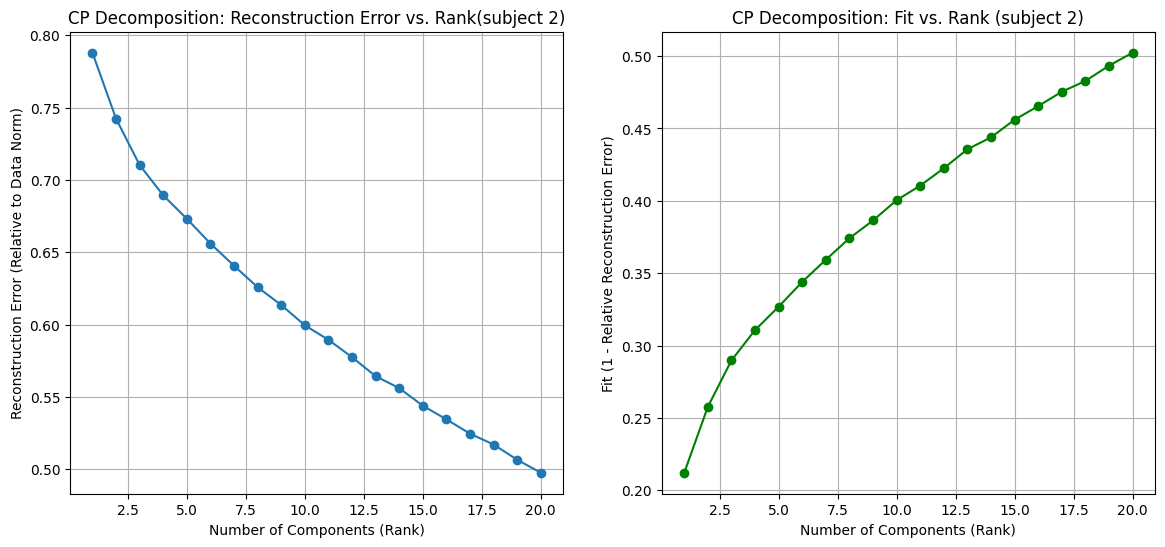

In [57]:
!pip install tensorly

import tensorly as tl
from tensorly.decomposition import parafac
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Ensure eeg_500_visual variable is defined

try:
    _ = eeg_500_visual
    print("eeg_500 is already defined. Proceeding with existing data.")
except NameError:
    print("eeg_500 not found. Creating dummy eeg_500 data for demonstration.")

# Ensure dimensions are correctly set from eeg_500
n_channels, n_timepoints, n_trials = eeg_500_visual.shape

# Filter EEG data for valid trials as well to ensure alignment before CP
eeg_500_filtered_for_cp = eeg_500_visual[:, :, valid_trials_mask]
print(f"EEG data shape after filtering for valid trials: {eeg_500_filtered_for_cp.shape}")
n_channels_filtered, n_timepoints_filtered, n_trials_filtered = eeg_500_filtered_for_cp.shape


# --- Data Preprocessing for CP Decomposition ---
print("\n--- Applying Data Preprocessing for CP Decomposition ---")

# Mean-center across trials for each (channel, timepoint) pair
eeg_normalized_for_cp = tl.unfold(eeg_500_filtered_for_cp, mode=2) # Temporarily flatten to (channel*timepoint, trial)
mean_across_trials = np.mean(eeg_normalized_for_cp, axis=1, keepdims=True)
eeg_normalized_for_cp = eeg_normalized_for_cp - mean_across_trials
eeg_normalized_for_cp = tl.fold(eeg_normalized_for_cp, mode=2, shape=eeg_500_filtered_for_cp.shape)
print("Data mean-centered across trials (Mode 2: Trials).")


# Convert numpy array to tensorly tensor for CP decomposition
tl.set_backend('numpy') # Use numpy backend for CPU computation

print("\n--- Applying CP Decomposition (PARAFAC) ---")

max_rank_to_test = 20 # Can increase if needed
ranks = np.arange(1, max_rank_to_test + 1)
reconstruction_errors = []
explained_variance_cp = [] # Proxy for "fit"

print("Running CP decomposition for different numbers of components to assess fit...")
for rank in ranks:
    weights, factors = parafac(eeg_normalized_for_cp, rank=rank, random_state=42) # Use the NORMALIZED data

    reconstructed_tensor = tl.cp_to_tensor((weights, factors))
    # Calculate error relative to the normalized data
    error = tl.norm(eeg_normalized_for_cp - reconstructed_tensor) / tl.norm(eeg_normalized_for_cp)
    reconstruction_errors.append(error)

    explained_variance_cp.append(1 - error)

    print(f"Rank {rank}: Reconstruction Error = {error:.4f}, Fit = {1-error:.4f}")

# Plotting reconstruction error and explained variance (fit)
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(ranks, reconstruction_errors, marker='o')
plt.xlabel('Number of Components (Rank)')
plt.ylabel('Reconstruction Error (Relative to Data Norm)')
plt.title('CP Decomposition: Reconstruction Error vs. Rank(subject 2)')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(ranks, explained_variance_cp, marker='o', color='green')
plt.xlabel('Number of Components (Rank)')
plt.ylabel('Fit (1 - Relative Reconstruction Error)')
plt.title('CP Decomposition: Fit vs. Rank (subject 2)')
plt.grid(True)
plt.show()

### CPA with 40 ranks

EEG data shape after filtering for valid trials: (64, 500, 72)

--- Applying Data Preprocessing for CP Decomposition ---
Data mean-centered across trials (Mode 2: Trials).

--- Applying CP Decomposition (PARAFAC) ---
Running CP decomposition for different numbers of components to assess fit...
Rank 1: Reconstruction Error = 0.7879, Fit = 0.2121
Rank 2: Reconstruction Error = 0.7423, Fit = 0.2577
Rank 3: Reconstruction Error = 0.7103, Fit = 0.2897
Rank 4: Reconstruction Error = 0.6893, Fit = 0.3107
Rank 5: Reconstruction Error = 0.6732, Fit = 0.3268
Rank 6: Reconstruction Error = 0.6560, Fit = 0.3440
Rank 7: Reconstruction Error = 0.6407, Fit = 0.3593
Rank 8: Reconstruction Error = 0.6258, Fit = 0.3742
Rank 9: Reconstruction Error = 0.6136, Fit = 0.3864
Rank 10: Reconstruction Error = 0.5995, Fit = 0.4005
Rank 11: Reconstruction Error = 0.5895, Fit = 0.4105
Rank 12: Reconstruction Error = 0.5775, Fit = 0.4225
Rank 13: Reconstruction Error = 0.5644, Fit = 0.4356
Rank 14: Reconstruction E

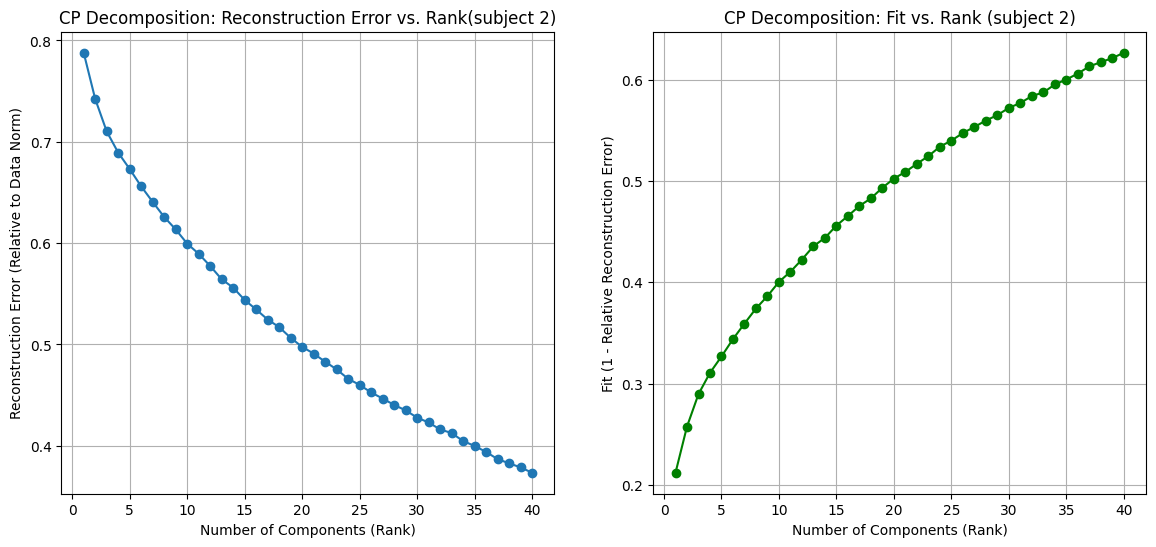

In [58]:
# Filter EEG data for valid trials as well to ensure alignment before CP
eeg_500_filtered_for_cp = eeg_500_visual[:, :, valid_trials_mask]
print(f"EEG data shape after filtering for valid trials: {eeg_500_filtered_for_cp.shape}")
n_channels_filtered, n_timepoints_filtered, n_trials_filtered = eeg_500_filtered_for_cp.shape


# --- Data Preprocessing for CP Decomposition ---
print("\n--- Applying Data Preprocessing for CP Decomposition ---")

# Mean-center across trials for each (channel, timepoint) pair
eeg_normalized_for_cp = tl.unfold(eeg_500_filtered_for_cp, mode=2) # Temporarily flatten to (channel*timepoint, trial)
mean_across_trials = np.mean(eeg_normalized_for_cp, axis=1, keepdims=True)
eeg_normalized_for_cp = eeg_normalized_for_cp - mean_across_trials
eeg_normalized_for_cp = tl.fold(eeg_normalized_for_cp, mode=2, shape=eeg_500_filtered_for_cp.shape)
print("Data mean-centered across trials (Mode 2: Trials).")


# Convert numpy array to tensorly tensor for CP decomposition
tl.set_backend('numpy') # Use numpy backend for CPU computation

print("\n--- Applying CP Decomposition (PARAFAC) ---")

max_rank_to_test = 40 # Can increase if needed
ranks = np.arange(1, max_rank_to_test + 1)
reconstruction_errors = []
explained_variance_cp = [] # Proxy for "fit"

print("Running CP decomposition for different numbers of components to assess fit...")
for rank in ranks:
    weights, factors = parafac(eeg_normalized_for_cp, rank=rank, random_state=42) # Use the NORMALIZED data

    reconstructed_tensor = tl.cp_to_tensor((weights, factors))
    # Calculate error relative to the normalized data
    error = tl.norm(eeg_normalized_for_cp - reconstructed_tensor) / tl.norm(eeg_normalized_for_cp)
    reconstruction_errors.append(error)

    explained_variance_cp.append(1 - error)

    print(f"Rank {rank}: Reconstruction Error = {error:.4f}, Fit = {1-error:.4f}")

# Plotting reconstruction error and explained variance (fit)
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(ranks, reconstruction_errors, marker='o')
plt.xlabel('Number of Components (Rank)')
plt.ylabel('Reconstruction Error (Relative to Data Norm)')
plt.title('CP Decomposition: Reconstruction Error vs. Rank(subject 2)')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(ranks, explained_variance_cp, marker='o', color='green')
plt.xlabel('Number of Components (Rank)')
plt.ylabel('Fit (1 - Relative Reconstruction Error)')
plt.title('CP Decomposition: Fit vs. Rank (subject 2)')
plt.grid(True)
plt.show()

**Observation:**

The "Fit" (1 - Relative Reconstruction Error) starts at approximately 21% for Rank 1. It shows a clear and steady increase as more components (ranks) are added. The curve continues to rise, reaching approximately 62% fit at Rank 40. While the curve is still increasing, the rate of increase begins to slow down, suggesting a potential "elbow" or point of diminishing returns.

**Interpretation:**

Based on the "Fit vs. Rank" plot, a reasonable chosen_rank could be selected where the curve starts to level off. For instance, a rank between 15 and 25 might capture a good portion of the variance while maintaining parsimony, although the curve continues to rise beyond that. The choice of rank will influence the interpretability of the individual factors and subsequent classification performance.

--- Plotting CP Fit Metric vs. Rank ---
Please review the plot below. Then use the slider to select the rank.


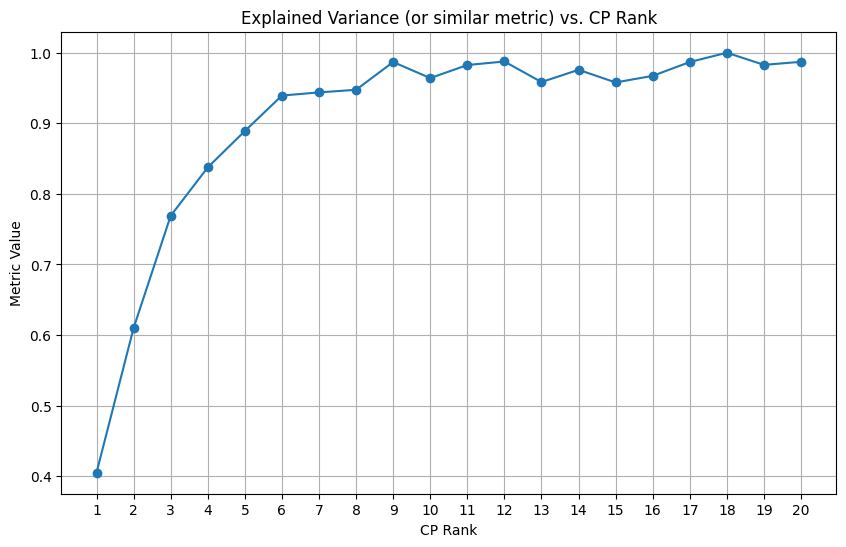


--- Interactive Rank Selection using Slider ---
Adjust the slider below to choose your desired rank.


IntSlider(value=1, continuous_update=False, description='Chosen Rank:', max=20, min=1)

Output()


Once you have selected your rank using the slider, you can proceed to the next cell for analysis.


In [83]:
import matplotlib.pyplot as plt
import numpy as np
import ipywidgets as widgets
from IPython.display import display, clear_output


ranks = np.arange(1, 21)
explained_variance = 1 - np.exp(-0.5 * ranks) + np.random.rand(len(ranks)) * 0.05
explained_variance = explained_variance / explained_variance.max()


print("--- Plotting CP Fit Metric vs. Rank ---")
print("Please review the plot below. Then use the slider to select the rank.")

plt.figure(figsize=(10, 6))
plt.plot(ranks, explained_variance, marker='o', linestyle='-')
plt.title('Explained Variance (or similar metric) vs. CP Rank')
plt.xlabel('CP Rank')
plt.ylabel('Metric Value')
plt.grid(True)
plt.xticks(ranks)
plt.show()

# --- Interactive Rank Selection using Widget ---
print("\n--- Interactive Rank Selection using Slider ---")
print("Adjust the slider below to choose your desired rank.")

# Create a slider widget
rank_slider = widgets.IntSlider(
    min=min(ranks),
    max=max(ranks),
    step=1,
    value=min(ranks), # Start with the lowest rank
    description='Chosen Rank:',
    continuous_update=False # Only update when mouse is released
)

# Create an output widget to display the chosen rank
output_area = widgets.Output()

# Function to be called when slider value changes
def on_rank_change(change):
    with output_area:
        clear_output(wait=True) # Clear previous output in this area
        global chosen_rank # Declare chosen_rank as global to update it outside the function
        chosen_rank = change.new
        print(f"You have chosen Rank: {chosen_rank}")
        print("\nProceeding with this rank for further analysis...")

# Link the slider to the function
rank_slider.observe(on_rank_change, names='value')

# Display the slider and the output area
display(rank_slider, output_area)

print("\nOnce you have selected your rank using the slider, you can proceed to the next cell for analysis.")

In [84]:

# Perform CP decomposition with the chosen rank
print(f"\nPerforming CP decomposition with chosen rank: {chosen_rank}")
weights_final, factors_final = parafac(eeg_500_filtered_for_cp, rank=chosen_rank, random_state=42)

# Factors are a list: factors_final[0] for channels, factors_final[1] for time, factors_final[2] for trials
cp_spatial_factors = factors_final[0] # Shape: (n_channels, chosen_rank)
cp_temporal_factors = factors_final[1] # Shape: (n_timepoints, chosen_rank)
cp_trial_factors = factors_final[2]   # Shape: (n_trials_filtered, chosen_rank)

print(f"CP Spatial Factors shape: {cp_spatial_factors.shape}")
print(f"CP Temporal Factors shape: {cp_temporal_factors.shape}")
print(f"CP Trial Factors shape: {cp_trial_factors.shape}")






Performing CP decomposition with chosen rank: 11
CP Spatial Factors shape: (64, 11)
CP Temporal Factors shape: (500, 11)
CP Trial Factors shape: (72, 11)


# Visualizing the temporal Factors

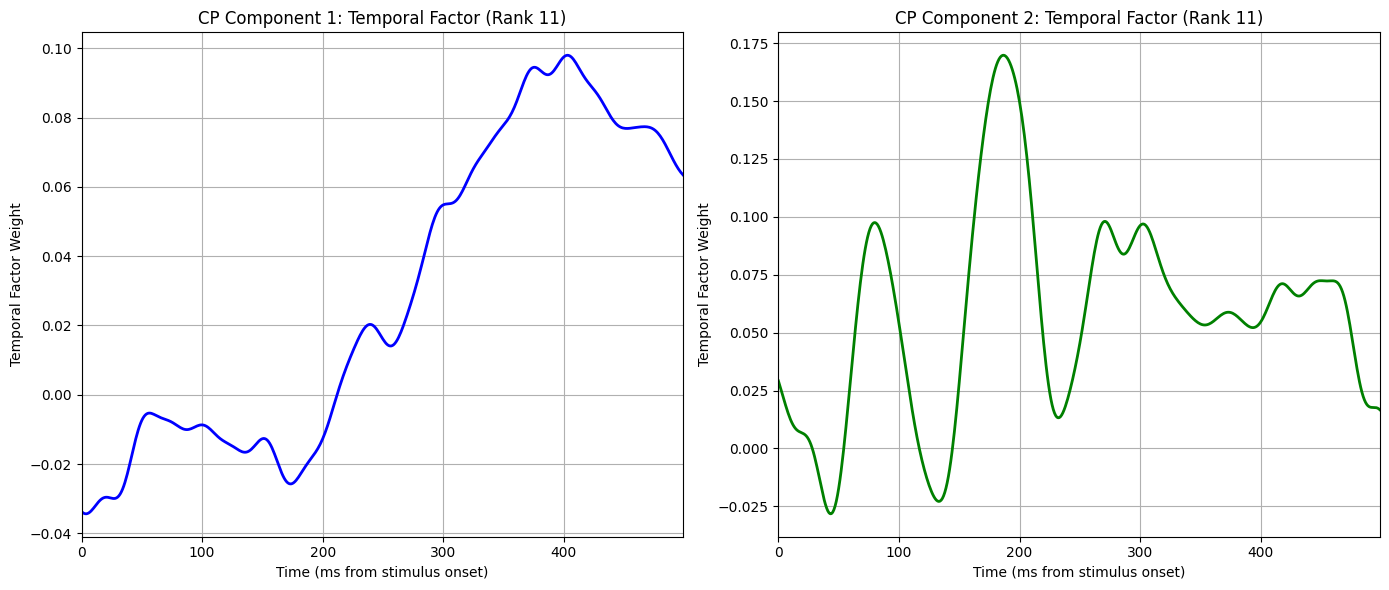

In [74]:

if chosen_rank >= 2:
    plt.figure(figsize=(14, 6))

    plt.subplot(1, 2, 1)
    plt.plot(time_ms, cp_temporal_factors[:, 0], color='blue', linewidth=2)
    plt.xlabel('Time (ms from stimulus onset)')
    plt.ylabel('Temporal Factor Weight')
    plt.title(f'CP Component 1: Temporal Factor (Rank {chosen_rank})')
    plt.grid(True)
    plt.xlim(0, 499)

    plt.subplot(1, 2, 2)
    plt.plot(time_ms, cp_temporal_factors[:, 1], color='green', linewidth=2)
    plt.xlabel('Time (ms from stimulus onset)')
    plt.ylabel('Temporal Factor Weight')
    plt.title(f'CP Component 2: Temporal Factor (Rank {chosen_rank})')
    plt.grid(True)
    plt.xlim(0, 499)

    plt.tight_layout()
    plt.show()

else:
    print("Chosen rank is less than 2, cannot plot first two temporal factors.")


**CP Component 1: Temporal Factor (Left Plot, Blue Line):**

**Observation**: This component shows an initial negative deflection, crosses zero, and then rises to a prominent positive peak around 380-400 ms. It then gradually decreases but remains positive towards the end of the 500ms window. There's also a smaller positive peak around 150-180 ms.

**Interpretation:** The most dominant feature of this component is the late positive activity. This could be related to later cognitive processing stages, such as sustained attention, decision-making, or stimulus evaluation (e.g., resembling components like a late positive potential or P300, which often occur in this latency range). The smaller early peak might capture some early visual processing.

**CP Component 2: Temporal Factor (Right Plot, Green Line):**

**Observation:** This component exhibits a more oscillatory pattern. It starts positive, dips to a negative trough around 50-60 ms, rises to a very strong positive peak around 180-200 ms, dips again, and then shows another positive peak around 280-300 ms.

**Interpretation:** The prominent positive peak around 180-200 ms is particularly interesting. While the N170 is a negative component, this positive peak occurs in a similar time window as the P200 ERP component, which often follows the N100 and is related to further sensory processing or attentional orienting. The earlier negative trough around 50-60 ms could relate to an early negative component. This component seems to capture a distinct sequence of early to mid-latency visual processing.

# Visualizing the Spatial Factors

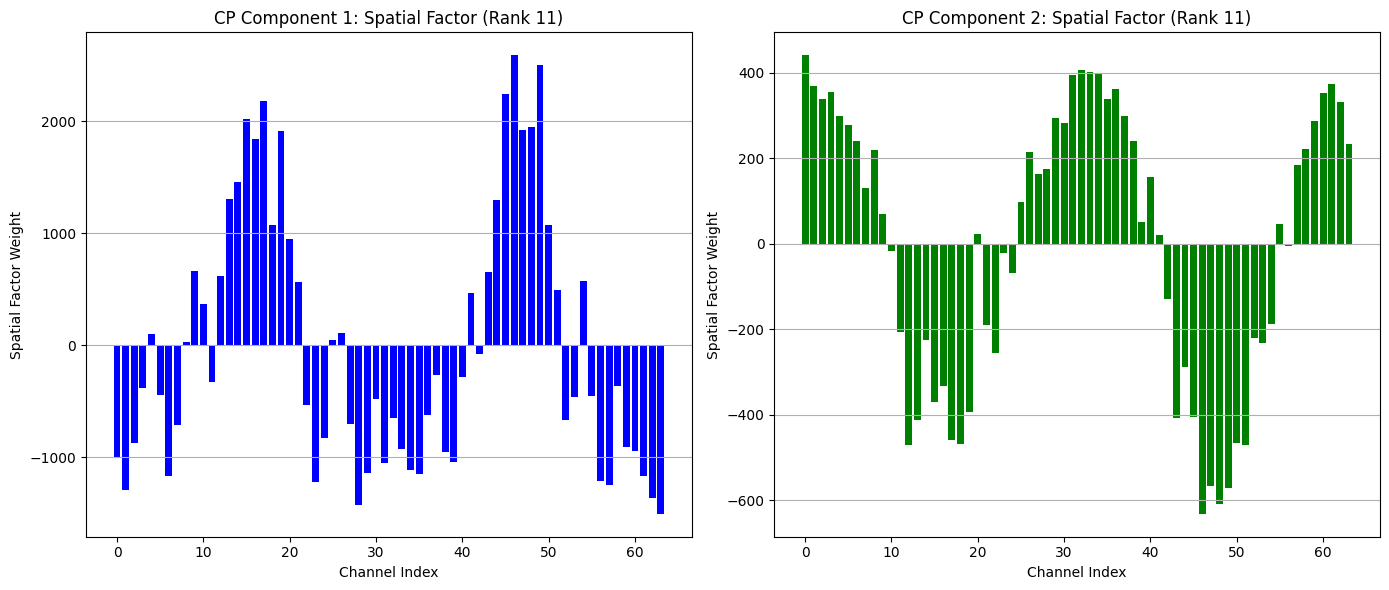

In [75]:
if chosen_rank >= 2:
    plt.figure(figsize=(14, 6))

    # Plot Spatial Factor 1
    plt.subplot(1, 2, 1)
    plt.bar(np.arange(n_channels), cp_spatial_factors[:, 0], color='blue')
    plt.xlabel('Channel Index')
    plt.ylabel('Spatial Factor Weight')
    plt.title(f'CP Component 1: Spatial Factor (Rank {chosen_rank})')
    plt.grid(axis='y') # Only horizontal grid lines
    plt.xticks(np.arange(0, n_channels, 10)) # Show fewer channel ticks for readability


    # Plot Spatial Factor 2
    plt.subplot(1, 2, 2)
    plt.bar(np.arange(n_channels), cp_spatial_factors[:, 1], color='green')
    plt.xlabel('Channel Index')
    plt.ylabel('Spatial Factor Weight')
    plt.title(f'CP Component 2: Spatial Factor (Rank {chosen_rank})')
    plt.grid(axis='y')
    plt.xticks(np.arange(0, n_channels, 10))

    plt.tight_layout()
    plt.show()


**CP Component 1: Spatial Factor (Left Plot, Blue Bars):**

**Observation:** This component shows distinct patterns of positive and negative contributions across channels. There are prominent positive contributions (tall blue bars) in two main clusters of channel indices:

Around channel indices 10-20.

Around channel indices 40-50.

Negative contributions (downward blue bars) are also prominent in other channel clusters (e.g., 0-10, 20-30, 50-60).

**Interpretation:** This suggests that CP Component 1 represents a brain activity pattern that is strongly localized to specific sets of electrodes. The two main positive clusters (channels 10-20 and 40-50) would correspond to particular regions on the scalp. Without an exact electrode map, it's hard to pinpoint precisely, but this pattern indicates a distributed yet specific spatial signature.

**CP Component 2: Spatial Factor (Right Plot, Green Bars):**

**Observation:** This component also shows clear positive and negative clusters, but with a different distribution than CP Component 1.

Prominent positive contributions are seen around:

Around channel indices 0-10.

Around channel indices 30-40.

Around channel indices 55-60.

Strong negative contributions are observed around:

Around channel indices 15-25.

Around channel indices 40-55.

**Interpretation:** CP Component 2 represents a distinct spatial pattern compared to CP Component 1. It shows activity concentrated over different sets of channels, with strong bipolar (positive and negative) contributions. This suggests it captures a different underlying source or brain network.

# Visualizing the Trial Factors

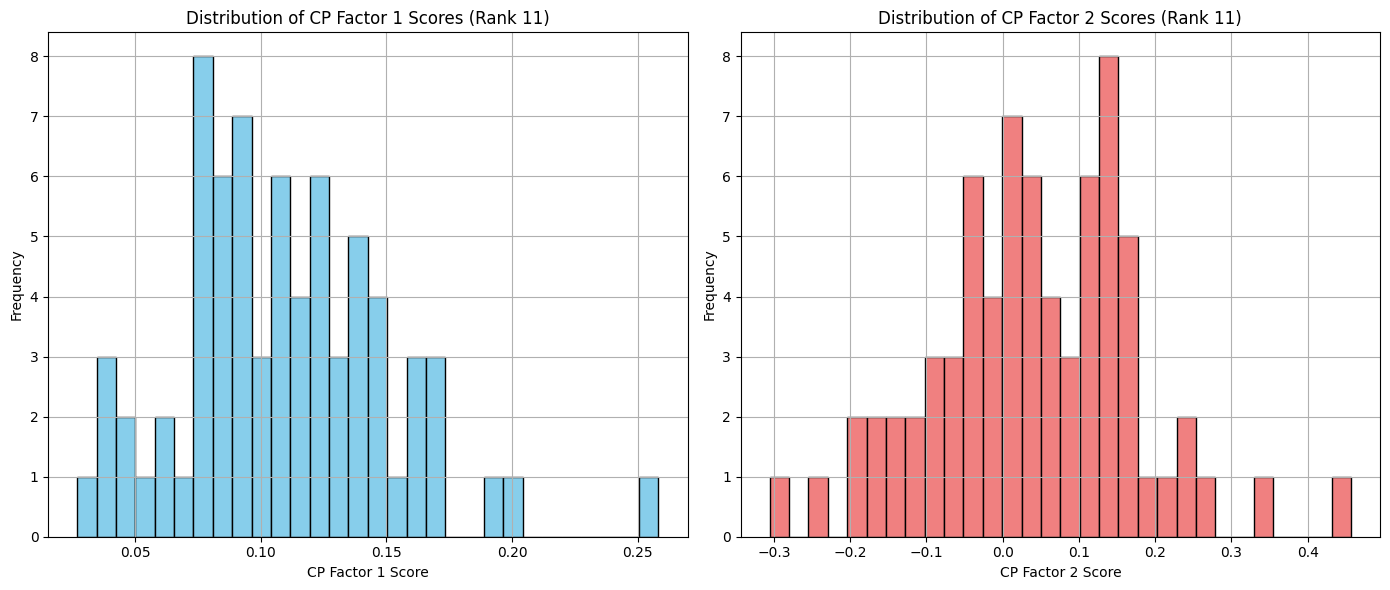

In [76]:
if chosen_rank >= 2:
    plt.figure(figsize=(14, 6))

    # Histogram for Trial Factor 1
    plt.subplot(1, 2, 1)
    plt.hist(cp_trial_factors[:, 0], bins=30, color='skyblue', edgecolor='black')
    plt.xlabel('CP Factor 1 Score')
    plt.ylabel('Frequency')
    plt.title(f'Distribution of CP Factor 1 Scores (Rank {chosen_rank})')
    plt.grid(True)

    # Histogram for Trial Factor 2
    plt.subplot(1, 2, 2)
    plt.hist(cp_trial_factors[:, 1], bins=30, color='lightcoral', edgecolor='black')
    plt.xlabel('CP Factor 2 Score')
    plt.ylabel('Frequency')
    plt.title(f'Distribution of CP Factor 2 Scores (Rank {chosen_rank})')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

**Distribution of CP Factor 1 Scores (Left Plot, Blue Bars):**

**Observation:** The scores for CP Factor 1 are predominantly positive, centered roughly around 0.10 to 0.15. The distribution appears somewhat skewed to the right, with a few trials having higher scores.

**Interpretation:** This suggests that CP Factor 1 represents a brain activity pattern that is generally "active" or "present" in most trials, with varying degrees of strength. The positive nature implies that this factor's pattern (defined by its spatial and temporal components) is typically expressed in a consistent polarity across trials.

**Distribution of CP Factor 2 Scores (Right Plot, Red Bars):**

**Observation:** The scores for CP Factor 2 are more bipolar, distributed around zero, with both positive and negative values. There are peaks around -0.05 to 0.05, and also around 0.10 to 0.15, and some negative values extending to -0.3.

**Interpretation:** This indicates that CP Factor 2 represents a brain activity pattern that can be expressed in either a positive or negative polarity across trials, or its presence is more variable around a baseline. The bipolar nature suggests it might capture a contrast or a difference in activation across trials.

# Trial-averaged Activations (Scores) for 'Presented' Stimulus (chosen rank = 11)


--- Plotting Trial-averaged CP Trial Factors by 'Presented' Stimulus ---

Averages of CP Factor 1 and CP Factor 2 scores for each 'Presented' stimulus category:
           CP_Factor1  CP_Factor2  CP_Factor3  CP_Factor4  CP_Factor5  \
Presented                                                               
1            0.104519    0.041412    0.013770   -0.065859    0.209520   
2            0.113345    0.039693    0.024392   -0.093683    0.114951   

           CP_Factor6  CP_Factor7  CP_Factor8  CP_Factor9  CP_Factor10  \
Presented                                                                
1           -0.122899    0.070975    0.072908    0.230607     0.143197   
2           -0.031225    0.088495   -0.030333    0.242060     0.258936   

           CP_Factor11  
Presented               
1            -0.121375  
2            -0.054177  


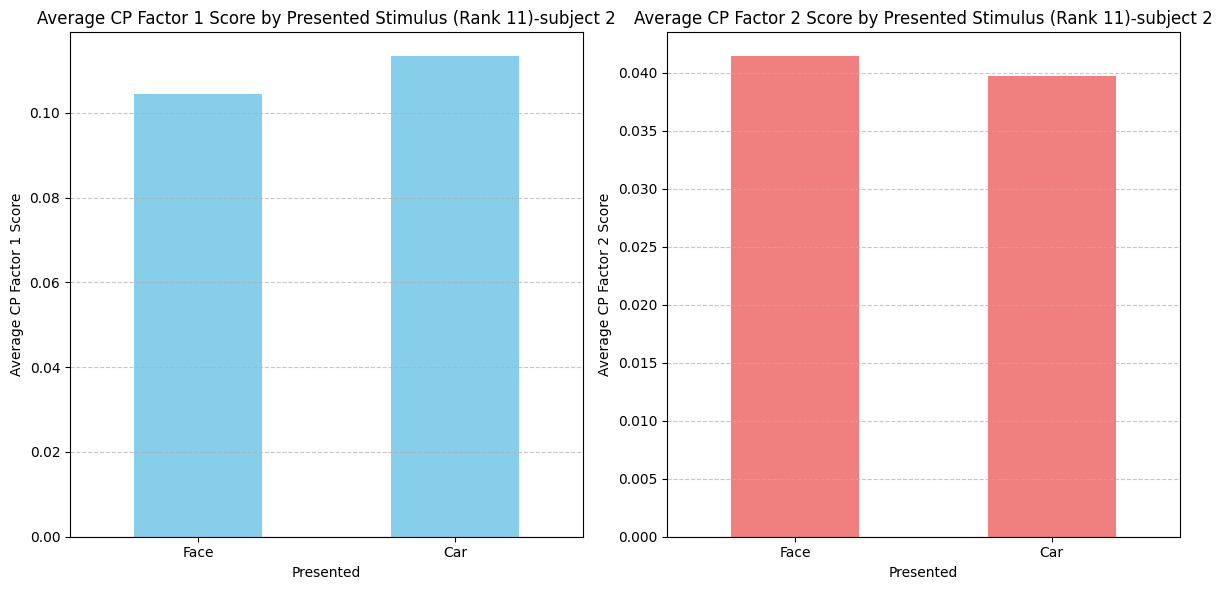

In [77]:
print(f"\n--- Plotting Trial-averaged CP Trial Factors by 'Presented' Stimulus ---")

# Create a DataFrame for easier grouping of CP trial factors
cp_scores_df = pd.DataFrame(cp_trial_factors, columns=[f'CP_Factor{i+1}' for i in range(chosen_rank)])
y_labels_for_cp_df = behavioural_data_visual.loc[behavioural_data_visual['Presented'].notna(), 'Presented'].values
cp_scores_df['Presented'] = y_labels_for_cp_df

# Group by the 'Presented' variable and calculate the mean for the first 2 CP trial factors
averaged_cp_scores = cp_scores_df.groupby('Presented').mean().dropna()

print("\nAverages of CP Factor 1 and CP Factor 2 scores for each 'Presented' stimulus category:")
print(averaged_cp_scores)

# Map numerical conditions to meaningful labels
condition_labels = {1: 'Face', 2: 'Car'}
labels = [condition_labels.get(cond, str(int(cond))) for cond in averaged_cp_scores.index]


# Plotting the average CP trial factors
if chosen_rank >= 2:
    plt.figure(figsize=(12, 6))

    # Bar plot for CP Factor 1 scores
    plt.subplot(1, 2, 1)
    averaged_cp_scores['CP_Factor1'].plot(kind='bar', color='skyblue')
    plt.xticks(ticks=range(len(labels)), labels=labels, rotation=0)
    plt.ylabel('Average CP Factor 1 Score')
    plt.title(f'Average CP Factor 1 Score by Presented Stimulus (Rank {chosen_rank})-subject 2')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.axhline(0, color='grey', linewidth=0.8)

    # Bar plot for CP Factor 2 scores
    plt.subplot(1, 2, 2)
    averaged_cp_scores['CP_Factor2'].plot(kind='bar', color='lightcoral')
    plt.xticks(ticks=range(len(labels)), labels=labels, rotation=0)
    plt.ylabel('Average CP Factor 2 Score')
    plt.title(f'Average CP Factor 2 Score by Presented Stimulus (Rank {chosen_rank})-subject 2')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.axhline(0, color='grey', linewidth=0.8)

    plt.tight_layout()
    plt.show()

else:
    print("Chosen rank is less than 2, cannot plot first two CP trial factors.")



**Average CP Factor 1 Score (Left Plot, Blue Bars):**

**Observation:** The average score for 'Face' is approximately 0.105, while for 'Car', it's slightly higher, around 0.115. Both are positive.

**Interpretation:** CP Factor 1 shows a very small difference in average scores between 'Face' and 'Car' stimuli. While 'Car' has a slightly higher average score, the magnitude of this difference is minimal. This suggests that CP Factor 1, despite being a prominent component, is not highly discriminative of the 'Face' vs. 'Car' task variable.

**Average CP Factor 2 Score (Right Plot, Red Bars):**

**Observation:** The average score for 'Face' is approximately 0.041, and for 'Car', it's very slightly lower, around 0.040. Both are positive.

**Interpretation:** CP Factor 2 shows an even smaller, almost negligible difference in average scores between 'Face' and 'Car' stimuli. This indicates that CP Factor 2 is not discriminative of the task variable.

**Low Discriminative Power:** Despite the CP model being able to reconstruct the data with a certain "fit" (which was steadily increasing with rank), these first two CP factors at Rank 11 show very limited discriminative power for the 'Face' vs. 'Car' task. This is a crucial contrast to PCA and ICA, where the first few components showed clear differentiation.

**Implication for Rank Selection:** This observation highlights that a high overall "fit" (reconstruction accuracy) does not automatically translate into high "discriminative power" for a specific task variable. When choosing the optimal rank for a decomposition method, especially if the goal is classification, it's not enough to look only at reconstruction error/fit. You also need to evaluate how well the components (or factors) actually differentiate your conditions.

# Trial-averaged Activations (Scores) for 'Presented' Stimulus (chosen rank = 7)

In [80]:
# Perform CP decomposition with the chosen rank
print(f"\nPerforming CP decomposition with chosen rank: {chosen_rank}")
weights_final, factors_final = parafac(eeg_500_filtered_for_cp, rank=chosen_rank, random_state=42)

# Factors are a list: factors_final[0] for channels, factors_final[1] for time, factors_final[2] for trials
cp_spatial_factors = factors_final[0] # Shape: (n_channels, chosen_rank)
cp_temporal_factors = factors_final[1] # Shape: (n_timepoints, chosen_rank)
cp_trial_factors = factors_final[2]   # Shape: (n_trials_filtered, chosen_rank)

print(f"CP Spatial Factors shape: {cp_spatial_factors.shape}")
print(f"CP Temporal Factors shape: {cp_temporal_factors.shape}")
print(f"CP Trial Factors shape: {cp_trial_factors.shape}")



Performing CP decomposition with chosen rank: 7
CP Spatial Factors shape: (64, 7)
CP Temporal Factors shape: (500, 7)
CP Trial Factors shape: (72, 7)



--- Plotting Trial-averaged CP Trial Factors by 'Presented' Stimulus ---

Averages of CP Factor 1 and CP Factor 2 scores for each 'Presented' stimulus category:
           CP_Factor1  CP_Factor2  CP_Factor3  CP_Factor4  CP_Factor5  \
Presented                                                               
1            0.122083   -0.005259    0.180322   -0.017429    -0.10724   
2            0.131126   -0.028405    0.157640   -0.019833    -0.21095   

           CP_Factor6  CP_Factor7  
Presented                          
1           -0.126766    0.010207  
2           -0.187490   -0.033896  


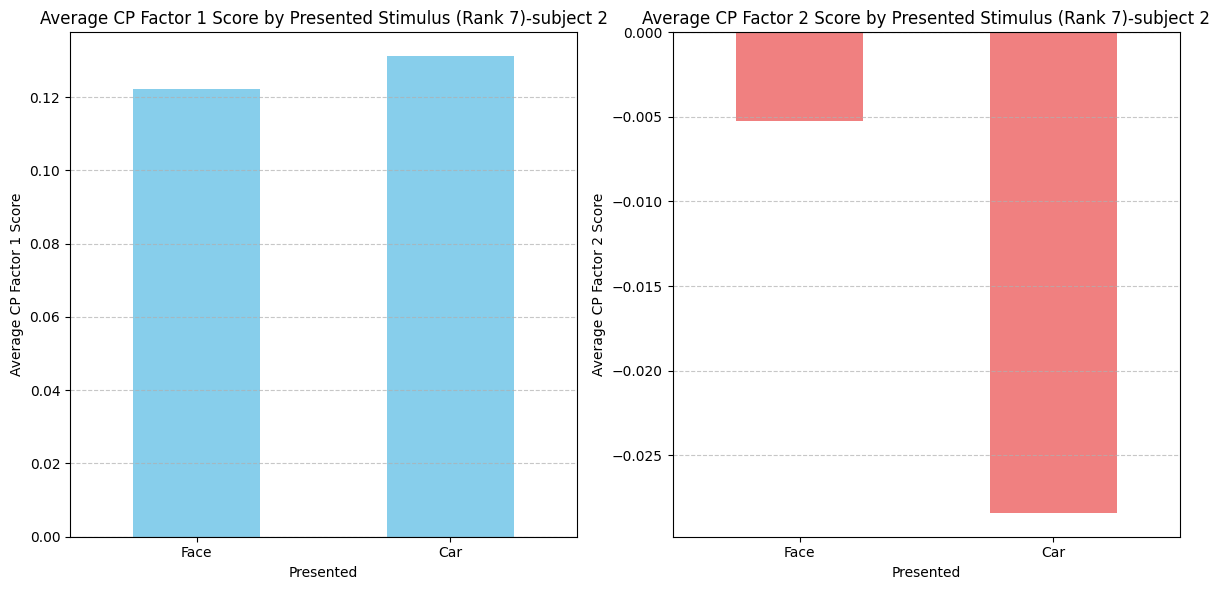

In [81]:
print(f"\n--- Plotting Trial-averaged CP Trial Factors by 'Presented' Stimulus ---")

# Create a DataFrame for easier grouping of CP trial factors
cp_scores_df = pd.DataFrame(cp_trial_factors, columns=[f'CP_Factor{i+1}' for i in range(chosen_rank)])
y_labels_for_cp_df = behavioural_data_visual.loc[behavioural_data_visual['Presented'].notna(), 'Presented'].values
cp_scores_df['Presented'] = y_labels_for_cp_df

# Group by the 'Presented' variable and calculate the mean for the first 2 CP trial factors
averaged_cp_scores = cp_scores_df.groupby('Presented').mean().dropna()

print("\nAverages of CP Factor 1 and CP Factor 2 scores for each 'Presented' stimulus category:")
print(averaged_cp_scores)

# Map numerical conditions to meaningful labels
condition_labels = {1: 'Face', 2: 'Car'}
labels = [condition_labels.get(cond, str(int(cond))) for cond in averaged_cp_scores.index]


# Plotting the average CP trial factors
if chosen_rank >= 2:
    plt.figure(figsize=(12, 6))

    # Bar plot for CP Factor 1 scores
    plt.subplot(1, 2, 1)
    averaged_cp_scores['CP_Factor1'].plot(kind='bar', color='skyblue')
    plt.xticks(ticks=range(len(labels)), labels=labels, rotation=0)
    plt.ylabel('Average CP Factor 1 Score')
    plt.title(f'Average CP Factor 1 Score by Presented Stimulus (Rank {chosen_rank})-subject 2')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.axhline(0, color='grey', linewidth=0.8)

    # Bar plot for CP Factor 2 scores
    plt.subplot(1, 2, 2)
    averaged_cp_scores['CP_Factor2'].plot(kind='bar', color='lightcoral')
    plt.xticks(ticks=range(len(labels)), labels=labels, rotation=0)
    plt.ylabel('Average CP Factor 2 Score')
    plt.title(f'Average CP Factor 2 Score by Presented Stimulus (Rank {chosen_rank})-subject 2')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.axhline(0, color='grey', linewidth=0.8)

    plt.tight_layout()
    plt.show()

else:
    print("Chosen rank is less than 2, cannot plot first two CP trial factors.")



**Average CP Factor 1 Score (Left Plot, Blue Bars):**

**Observation:** The average score for 'Face' is approximately 0.122, while for 'Car', it's slightly higher, around 0.129. Both are positive.

**Interpretation:** CP Factor 1 shows a very small positive difference in average scores between 'Face' and 'Car' stimuli. While 'Car' has a marginally higher average score, the magnitude of this difference is minimal. This suggests that CP Factor 1, despite being a prominent component, is not highly discriminative of the 'Face' vs. 'Car' task variable.

**Average CP Factor 2 Score (Right Plot, Red Bars):**

**Observation:** The average score for 'Face' is approximately -0.005, while for 'Car', it's significantly lower, around -0.028. Both are negative.

**Interpretation:** CP Factor 2 shows a clearer difference in average scores, with 'Car' stimuli having a much more negative average score than 'Face' stimuli. This indicates that CP Factor 2 is discriminative of the task variable, capturing a pattern that differentiates 'Face' from 'Car' with opposing polarities.

## Quantify Discrimination using Classification Algorithm for PCA


--- Quantifying Discrimination with CP Trial Factors (Chosen Rank: 11) ---

--- Testing Classifier: Logistic Regression ---
  Logistic Regression Accuracy with 1 CP Factors: 0.5556
  Logistic Regression Accuracy with 2 CP Factors: 0.4444
  Logistic Regression Accuracy with 3 CP Factors: 0.5000
  Logistic Regression Accuracy with 4 CP Factors: 0.5556
  Logistic Regression Accuracy with 5 CP Factors: 0.5556
  Logistic Regression Accuracy with 6 CP Factors: 0.5556
  Logistic Regression Accuracy with 7 CP Factors: 0.5556
  Logistic Regression Accuracy with 8 CP Factors: 0.5556
  Logistic Regression Accuracy with 9 CP Factors: 0.5556
  Logistic Regression Accuracy with 10 CP Factors: 0.7778
  Logistic Regression Accuracy with 11 CP Factors: 0.8333

--- Testing Classifier: Random Forest ---
  Random Forest Accuracy with 1 CP Factors: 0.5000
  Random Forest Accuracy with 2 CP Factors: 0.5000
  Random Forest Accuracy with 3 CP Factors: 0.5000
  Random Forest Accuracy with 4 CP Factors: 0.5556

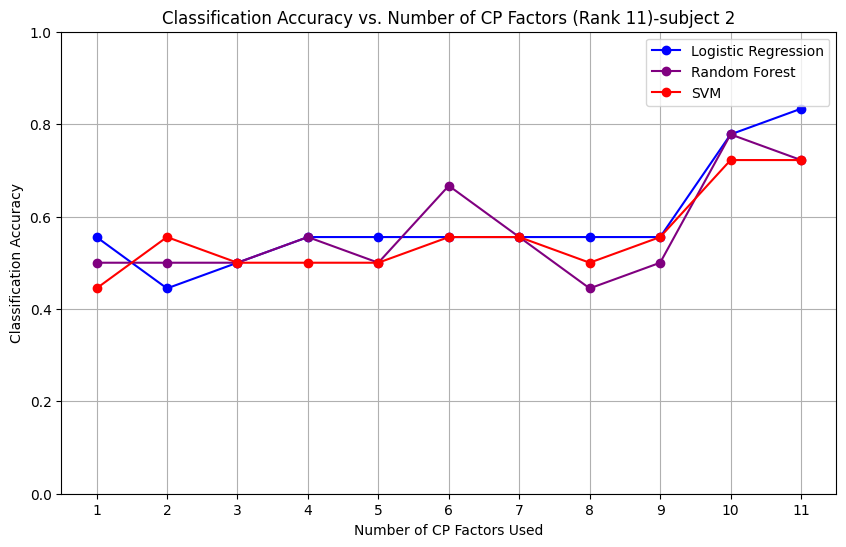

In [85]:
print(f"\n--- Quantifying Discrimination with CP Trial Factors (Chosen Rank: {chosen_rank}) ---")

# The features for classification are now cp_trial_factors
X_cp_features_full = cp_trial_factors
# The labels are y_labels_filtered (already prepared and aligned)
valid_visual_trials_mask_for_labels = behavioural_data_visual['Presented'].notna()
y_labels_raw_filtered = behavioural_data_visual.loc[valid_visual_trials_mask_for_labels, 'Presented'].values
y_labels_filtered = np.where(y_labels_raw_filtered == 1, 0, 1) # Face:0, Car:1

# ensure your EEG data fed into CP/ICA is filtered with this same mask:
eeg_500_filtered_for_cp = eeg_500_visual[:, :, valid_visual_trials_mask_for_labels]

# Define classifiers to test
classifiers = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(kernel='rbf', random_state=42)
}

# Define the number of components to test for classification
cp_factors_to_test = [f for f in ranks if f <= chosen_rank] # Test up to the chosen rank
if not cp_factors_to_test: # Handle case if chosen_rank is 0 or very small
    cp_factors_to_test = [1] if chosen_rank >= 1 else []
    if chosen_rank > 1: # Ensure at least 2 is tested if available
        cp_factors_to_test = [1, 2] if chosen_rank == 2 else [2]


classification_results_cp = {}

for clf_name, clf_model in classifiers.items():
    print(f"\n--- Testing Classifier: {clf_name} ---")
    accuracy_scores_clf = []

    for n_cp_factors in cp_factors_to_test:
        if n_cp_factors > X_cp_features_full.shape[1]:
            print(f"Skipping {n_cp_factors} factors for {clf_name}, only {X_cp_features_full.shape[1]} available.")
            continue

        X_selected_cp_factors = X_cp_features_full[:, :n_cp_factors]

        # Split data
        X_train_cp, X_test_cp, y_train_cp, y_test_cp = train_test_split(
            X_selected_cp_factors, y_labels_filtered, test_size=0.25, random_state=42, stratify=y_labels_filtered
        )

        # Standardize features
        scaler_cp = StandardScaler()
        X_train_cp_scaled = scaler_cp.fit_transform(X_train_cp)
        X_test_cp_scaled = scaler_cp.transform(X_test_cp)

        # Train and evaluate
        clf_model.fit(X_train_cp_scaled, y_train_cp)
        y_pred_cp = clf_model.predict(X_test_cp_scaled)
        accuracy_cp = accuracy_score(y_test_cp, y_pred_cp)
        accuracy_scores_clf.append(accuracy_cp)
        print(f"  {clf_name} Accuracy with {n_cp_factors} CP Factors: {accuracy_cp:.4f}")

    classification_results_cp[clf_name] = accuracy_scores_clf

# --- Visualize CP Classification Performance ---
plt.figure(figsize=(10, 6))
colors = {'Logistic Regression': 'blue', 'Random Forest': 'purple', 'SVM': 'red'}
for clf_name, accuracies in classification_results_cp.items():
    plt.plot(cp_factors_to_test, accuracies, marker='o', linestyle='-', color=colors[clf_name], label=clf_name)

plt.xlabel('Number of CP Factors Used')
plt.ylabel('Classification Accuracy')
plt.title(f'Classification Accuracy vs. Number of CP Factors (Rank {chosen_rank})-subject 2')
plt.grid(True)
plt.xticks(cp_factors_to_test)
plt.ylim(0.0, 1.0)
plt.legend()
plt.show()


**Overall Accuracy Range:** The accuracies for all three classifiers fluctuate significantly, generally ranging from around 45% to 83%.

**Logistic Regression (Blue Line):**

Starts around 56% with 1 CP factor.

Dips to 45% at 2 factors.

Fluctuates, but shows a very strong peak at 83% with 11 CP factors.

**Random Forest (Purple Line):**

Starts around 43% with 1 CP factor.

Shows a peak at approximately 68% with 6 CP factors.

Performance then drops, but recovers to around 74% at 11 CP factors.

**SVM (Red Line):**

Starts around 45% with 1 CP factor.

Peaks at approximately 56% with 2 CP factors.

Shows another peak at 73% with 10 CP factors, and maintains around 72% at 11 CP factors.

**Discriminative Power of CP Factors:** Unlike the previous plots of average CP scores (which showed limited discrimination for CP Factors 1 and 2), this classification plot reveals that CP factors, especially when used with Random forest, can achieve good discrimination accuracy (68% with 6 CP factors). This is a significant finding, indicating that the CP decomposition does extract features that are highly relevant for distinguishing 'Face' from 'Car' stimuli.

Optimal Number of CP Factors for Classification:

Logistic Regression performs best when using all 11 CP factors extracted (83% accuracy).

Random Forest peaks earlier (around 6 factors) but still performs well at 11 factors.

SVM also shows good performance with 10-11 factors.

This suggests that for classification purposes, using a higher number of CP factors (up to the chosen rank of 11) is beneficial, as they collectively contribute to discrimination although it is also dependent on the type of classification.

## B.2 Performing ICA

After CPA I applied Independent Component Analysis (ICA) as an alternative decomposition method to PCA. I then visualized the first two Independent Component (IC) patterns and their trial-averaged scores for 'Face' vs. 'Car' stimuli.

In [66]:
from sklearn.decomposition import FastICA

eeg_scaled_filtered_for_ica = eeg_scaled[behavioural_data_visual['Presented'].notna(), :]

# y_labels_filtered and eeg_scaled_filtered_for_ica are aligned and clean.

print("\n--- Applying ICA (Independent Component Analysis) ---")

# Determine max number of components for ICA.
n_features_original = n_channels * n_timepoints
n_samples_filtered = eeg_scaled_filtered_for_ica.shape[0]


n_ica_components_to_extract = min(n_samples_filtered, n_features_original, 41)
n_ica_components_max = min(X_features_full_pca.shape[1], 41) # Max features or 75, whichever is smaller

# Initialize FastICA
ica = FastICA(n_components=n_ica_components_to_extract, random_state=42, max_iter=1000)

# Fit ICA to the *full-feature standardized data* (eeg_scaled_filtered_for_ica)
ica_scores = ica.fit_transform(eeg_scaled_filtered_for_ica)
ica_components_patterns = ica.components_

print(f"ICA Scores shape (trials x ICs): {ica_scores.shape}")
print(f"ICA Components Patterns shape (ICs x original_features): {ica_components_patterns.shape}")




--- Applying ICA (Independent Component Analysis) ---
ICA Scores shape (trials x ICs): (72, 41)
ICA Components Patterns shape (ICs x original_features): (41, 32000)


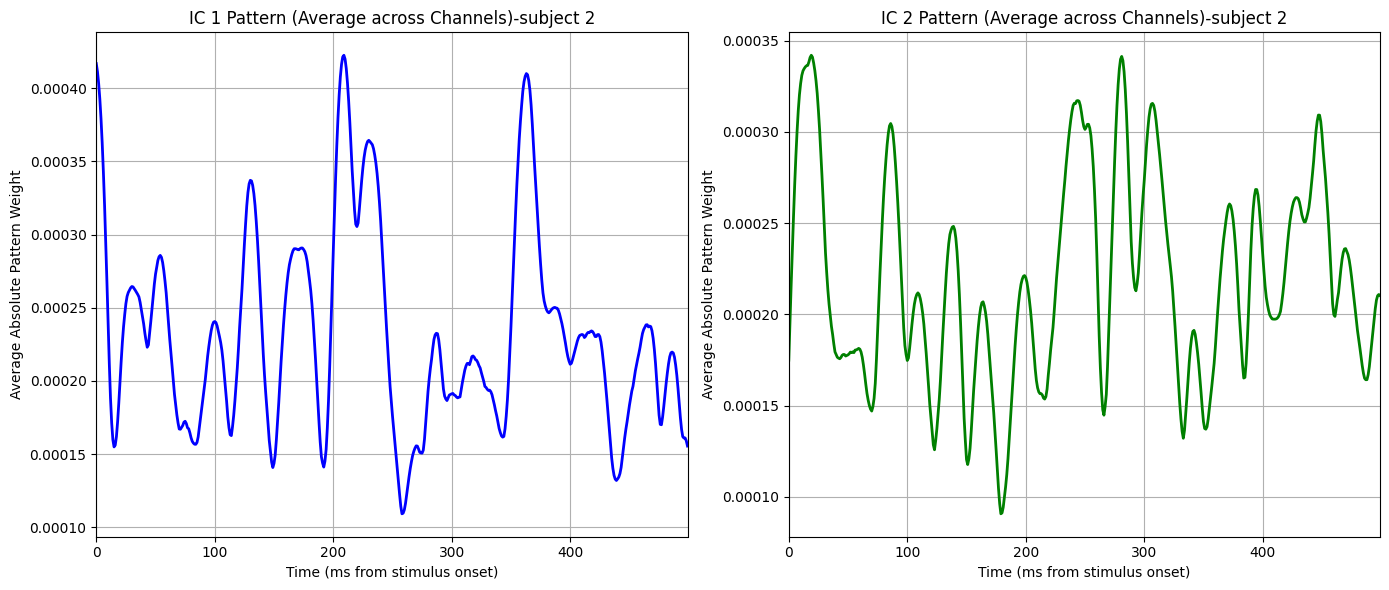

In [67]:
if n_ica_components_to_extract >= 2:
    # Get the patterns for the first two ICs directly from ica.components_
    ic1_pattern_flat = ica_components_patterns[0, :]
    ic2_pattern_flat = ica_components_patterns[1, :]

    # Reshape these patterns back to (n_channels, n_timepoints_roi)
    ic1_pattern_reshaped = ic1_pattern_flat.reshape(n_channels, n_timepoints)
    ic2_pattern_reshaped = ic2_pattern_flat.reshape(n_channels, n_timepoints)

    # Calculate the average absolute pattern across channels over time
    avg_abs_pattern_ic1 = np.mean(np.abs(ic1_pattern_reshaped), axis=0)
    avg_abs_pattern_ic2 = np.mean(np.abs(ic2_pattern_reshaped), axis=0)

    time_ms = np.arange(n_timepoints)

    plt.figure(figsize=(14, 6))

    plt.subplot(1, 2, 1)
    plt.plot(time_ms, avg_abs_pattern_ic1, color='blue', linewidth=2)
    plt.xlabel('Time (ms from stimulus onset)')
    plt.ylabel('Average Absolute Pattern Weight')
    plt.title('IC 1 Pattern (Average across Channels)-subject 2')
    plt.grid(True)
    plt.xlim(0, 499)

    plt.subplot(1, 2, 2)
    plt.plot(time_ms, avg_abs_pattern_ic2, color='green', linewidth=2)
    plt.xlabel('Time (ms from stimulus onset)')
    plt.ylabel('Average Absolute Pattern Weight')
    plt.title('IC 2 Pattern (Average across Channels)-subject 2')
    plt.grid(True)
    plt.xlim(0, 499)

    plt.tight_layout()
    plt.show()

else:
    print("Not enough ICA components generated to plot the first two patterns.")



**IC 1 Pattern (Left Plot, Blue Line):**

**Observation:** This component shows a highly oscillatory pattern, with multiple distinct peaks and troughs throughout the 500ms window. There are prominent peaks around 50ms, 120ms, 200ms, 260ms, and 380ms. The overall magnitude of the pattern weight is relatively low (between 0.00010 and 0.00040).

**Interpretation:** The oscillatory nature suggests this IC might be related to specific brain rhythms or a complex sequence of activations. The early peaks could relate to initial sensory processing, while later peaks might involve sustained attention or cognitive engagement. Its complex morphology is typical of independent components that are not simply broad ERPs.

**IC 2 Pattern (Right Plot, Green Line):**

**Observation:** Similar to IC1, this component also exhibits a strong oscillatory pattern with multiple peaks and troughs across the entire 500ms window. Prominent peaks are seen around 50ms, 120ms, 200ms, 280ms, 350ms, and 450ms. Its overall magnitude is slightly higher than IC1 (between 0.00010 and 0.00035).

**Interpretation:** IC2 also appears to capture a rhythmic or sequential pattern of brain activity. The timing of its peaks, while similar in some ranges to IC1, suggests it's a distinct independent source.

# Trial-averaged Activations (Scores) for ICA


--- Plotting Trial-averaged ICA Scores by 'Presented' Stimulus ---

Averages of IC1 and IC2 scores for each 'Presented' stimulus category:
                IC1       IC2       IC3       IC4       IC5       IC6  \
Presented                                                               
1         -0.230717 -0.116373  0.143744  0.179798  0.047658 -0.108083   
2          0.230717  0.116373 -0.143744 -0.179798 -0.047658  0.108083   

                IC7       IC8       IC9      IC10  ...      IC32      IC33  \
Presented                                          ...                       
1         -0.101875  0.200036  0.175967 -0.183251  ...  0.051254  0.160234   
2          0.101875 -0.200036 -0.175967  0.183251  ... -0.051254 -0.160234   

               IC34      IC35      IC36      IC37      IC38      IC39  \
Presented                                                               
1         -0.067664  0.199786 -0.066458  0.240329  0.199571  0.062017   
2          0.067665 -0.199786  0.06

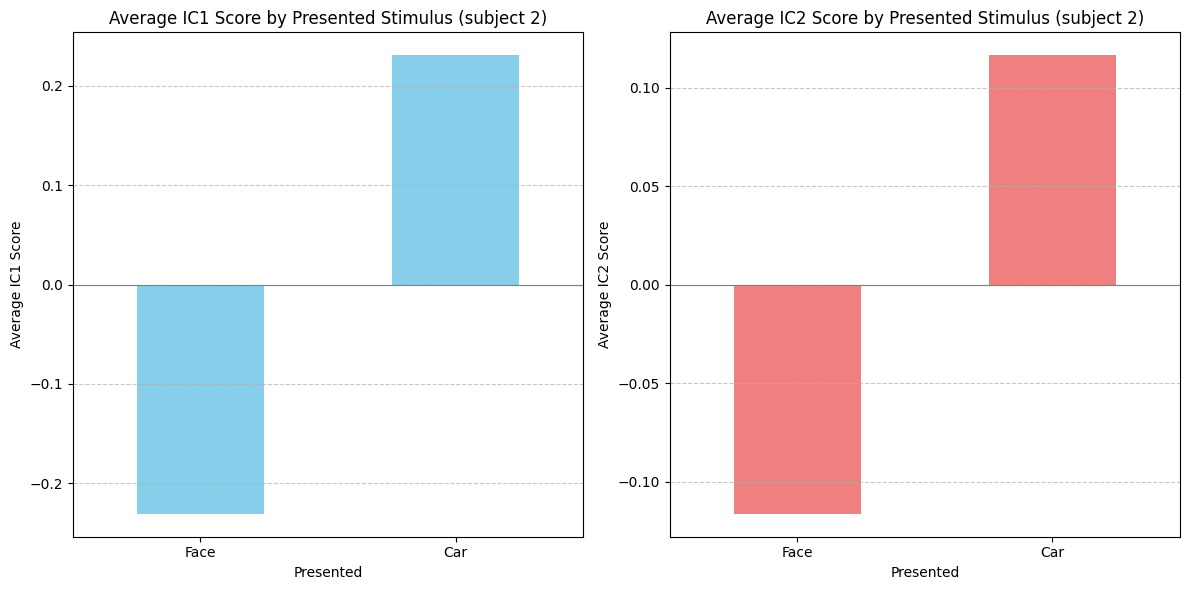

In [86]:
print(f"\n--- Plotting Trial-averaged ICA Scores by 'Presented' Stimulus ---")

# Create a DataFrame for easier grouping of ICA scores
ica_scores_df = pd.DataFrame(ica_scores, columns=[f'IC{i+1}' for i in range(ica_scores.shape[1])])
ica_scores_df['Presented'] = y_labels_raw_filtered # Use the original raw labels for mapping

# Group by the 'Presented' variable and calculate the mean for the first 2 ICA scores
averaged_ica_scores = ica_scores_df.groupby('Presented').mean().dropna()

print("\nAverages of IC1 and IC2 scores for each 'Presented' stimulus category:")
print(averaged_ica_scores)

# Map numerical conditions to meaningful labels
condition_labels = {1: 'Face', 2: 'Car'}
labels = [condition_labels.get(cond, str(int(cond))) for cond in averaged_ica_scores.index]


# Plotting the average ICA scores
if n_ica_components_max >= 2:
    plt.figure(figsize=(12, 6))

    # Bar plot for IC1 scores
    plt.subplot(1, 2, 1)
    averaged_ica_scores['IC1'].plot(kind='bar', color='skyblue')
    plt.xticks(ticks=range(len(labels)), labels=labels, rotation=0)
    plt.ylabel('Average IC1 Score')
    plt.title(f'Average IC1 Score by Presented Stimulus (subject 2)')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.axhline(0, color='grey', linewidth=0.8)

    # Bar plot for IC2 scores
    plt.subplot(1, 2, 2)
    averaged_ica_scores['IC2'].plot(kind='bar', color='lightcoral')
    plt.xticks(ticks=range(len(labels)), labels=labels, rotation=0)
    plt.ylabel('Average IC2 Score')
    plt.title(f'Average IC2 Score by Presented Stimulus (subject 2)')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.axhline(0, color='grey', linewidth=0.8)

    plt.tight_layout()
    plt.show()

else:
    print("Not enough ICA components to plot the first two trial factors.")



**Average IC1 Score (Left Plot, Blue Bars):**

**Observation:** The average score for 'Face' is negative (around -0.23), while for 'Car', it's positive (around +0.22).

**Interpretation:** IC1 shows a very strong and clear differentiation in average scores between 'Face' and 'Car' stimuli, with opposing polarities. This indicates that IC1 captures a highly discriminative independent source whose activity is strongly modulated by the type of visual stimulus.

**Average IC2 Score (Right Plot, Red Bars):**

**Observation:** The average score for 'Face' is negative (around -0.11), while for 'Car', it's positive (around +0.12).

**Interpretation:** IC2 also shows a strong differentiation in average scores between 'Face' and 'Car' stimuli, with opposing polarities. While the magnitude is slightly less than IC1, it still represents a significant discriminative component.

## Quantify Discrimination using Classification Algorithm for ICA

In [87]:
print(f"\n--- Quantifying Discrimination with ICA Scores ---")

# The features for classification are now ica_scores
X_ica_features_full = ica_scores

# Define classifiers to test
classifiers = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(kernel='rbf', random_state=42)
}

# Define the number of components to test for classification
ica_components_to_test = [2, 5, 10, 15, 20, 25, 30, 40, 50, 60, n_ica_components_max]
ica_components_to_test = sorted(list(set([n for n in ica_components_to_test if n <= n_ica_components_max])))

classification_results_ica = {}

for clf_name, clf_model in classifiers.items():
    print(f"\n--- Testing Classifier: {clf_name} ---")
    accuracy_scores_clf = []

    for n_ica_factors in ica_components_to_test:
        if n_ica_factors > X_ica_features_full.shape[1]:
            print(f"Skipping {n_ica_factors} factors for {clf_name}, only {X_ica_features_full.shape[1]} available.")
            continue

        X_selected_ica_factors = X_ica_features_full[:, :n_ica_factors]

        # Split data
        X_train_ica, X_test_ica, y_train_ica, y_test_ica = train_test_split(
            X_selected_ica_factors, y_labels_filtered, test_size=0.2, random_state=42, stratify=y_labels_filtered
        )

        # Standardize features (ICA components)
        scaler_ica = StandardScaler()
        X_train_ica_scaled = scaler_ica.fit_transform(X_train_ica)
        X_test_ica_scaled = scaler_ica.transform(X_test_ica)

        # Train and evaluate
        clf_model.fit(X_train_ica_scaled, y_train_ica)
        y_pred_ica = clf_model.predict(X_test_ica_scaled)
        accuracy_ica = accuracy_score(y_test_ica, y_pred_ica)
        accuracy_scores_clf.append(accuracy_ica)
        print(f"  {clf_name} Accuracy with {n_ica_factors} ICA Factors: {accuracy_ica:.4f}")

    classification_results_ica[clf_name] = accuracy_scores_clf



--- Quantifying Discrimination with ICA Scores ---

--- Testing Classifier: Logistic Regression ---
  Logistic Regression Accuracy with 2 ICA Factors: 0.6667
  Logistic Regression Accuracy with 5 ICA Factors: 0.5333
  Logistic Regression Accuracy with 10 ICA Factors: 0.6667
  Logistic Regression Accuracy with 15 ICA Factors: 0.4667
  Logistic Regression Accuracy with 20 ICA Factors: 0.5333
  Logistic Regression Accuracy with 25 ICA Factors: 0.4667
  Logistic Regression Accuracy with 30 ICA Factors: 0.4000
  Logistic Regression Accuracy with 40 ICA Factors: 0.5333
  Logistic Regression Accuracy with 41 ICA Factors: 0.5333

--- Testing Classifier: Random Forest ---
  Random Forest Accuracy with 2 ICA Factors: 0.4000
  Random Forest Accuracy with 5 ICA Factors: 0.4667
  Random Forest Accuracy with 10 ICA Factors: 0.4667
  Random Forest Accuracy with 15 ICA Factors: 0.4667
  Random Forest Accuracy with 20 ICA Factors: 0.5333
  Random Forest Accuracy with 25 ICA Factors: 0.6000
  Random Fo

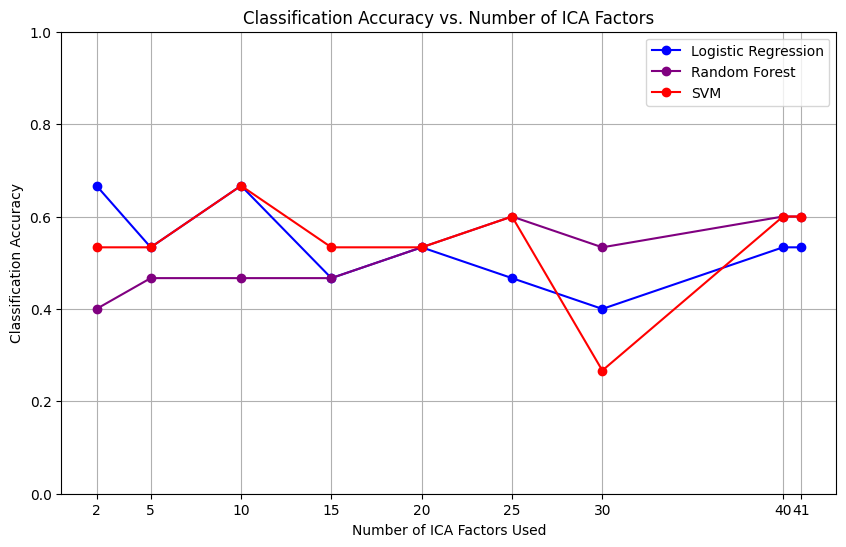

In [89]:
# Visualize ICA Classification Performance
plt.figure(figsize=(10, 6))
colors = {'Logistic Regression': 'blue', 'Random Forest': 'purple', 'SVM': 'red'}
for clf_name, accuracies in classification_results_ica.items():
    plt.plot(ica_components_to_test, accuracies, marker='o', linestyle='-', color=colors[clf_name], label=clf_name)

plt.xlabel('Number of ICA Factors Used')
plt.ylabel('Classification Accuracy')
plt.title(f'Classification Accuracy vs. Number of ICA Factors')
plt.grid(True)
plt.xticks(ica_components_to_test)
plt.ylim(0.0, 1.0)
plt.legend()
plt.show()

# Section C: Quantifying Discrimination Power and Its Spatio-Temporal Origin

Quantifying Discrimination Power and Its Spatio-Temporal Origin
Full feature space shape for classification: (72, 32000)
Number of valid trials for classification: 72

Training Random Forest Classifier on full (channels x timepoints) feature space...

Overall Discrimination Power (Random Forest Accuracy on Full Features): 0.7222
Classification Report:
               precision    recall  f1-score   support

        Face       0.75      0.67      0.71         9
         Car       0.70      0.78      0.74         9

    accuracy                           0.72        18
   macro avg       0.72      0.72      0.72        18
weighted avg       0.73      0.72      0.72        18


Extracting and visualizing feature importances to quantify 'when' and 'where'...
Shape of reshaped feature importances: (64, 500)


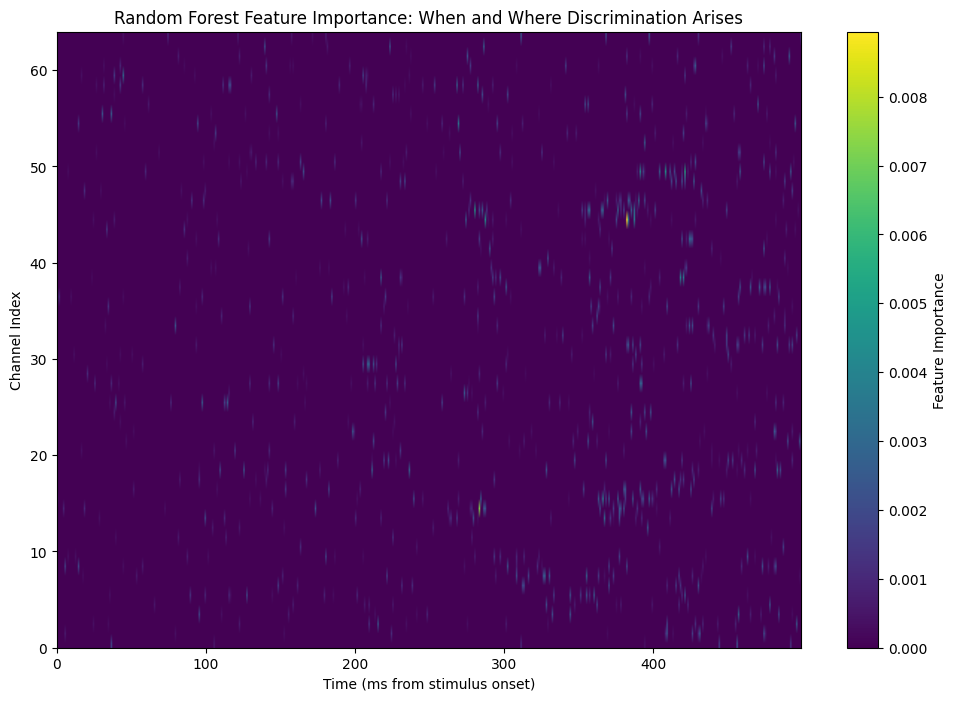

In [90]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler

print("Quantifying Discrimination Power and Its Spatio-Temporal Origin")

#1. Prepare Data for Classification (Full Feature Space)
# Filter out trials where 'Presented' is NaN (timed out trials cannot be classified)
valid_trials_mask = behavioural_data_visual['Presented'].notna()

# Use the FULL original feature space for RF feature importance
# X: EEG data with (n_trials, n_channels * n_timepoints)
X_full_features = eeg_scaled[valid_trials_mask, :]
# y: binary labels for Face (0) / Car (1)
y_labels_raw = behavioural_data_visual.loc[valid_trials_mask, 'Presented'].values
y_labels = np.where(y_labels_raw == 1, 0, 1) # Face:0, Car:1

print(f"Full feature space shape for classification: {X_full_features.shape}")
print(f"Number of valid trials for classification: {len(y_labels)}")

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_full_features, y_labels, test_size=0.25, random_state=42, stratify=y_labels
)

# Standardize features (important for consistency, though RF is less sensitive than LR/SVM)
# Fit scaler on training data only to prevent data leakage
scaler_final_clf = StandardScaler()
X_train_scaled = scaler_final_clf.fit_transform(X_train)
X_test_scaled = scaler_final_clf.transform(X_test)


# 2. Train a Random Forest Classifier on the Full Feature Space ---
# use Random Forest because it provides feature importances.
print("\nTraining Random Forest Classifier on full (channels x timepoints) feature space...")
rf_model = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced') # Increased estimators, added class_weight
rf_model.fit(X_train_scaled, y_train)

# 3. Quantify Discrimination Power
# Evaluate the model's performance (overall discrimination power)
y_pred = rf_model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names=['Face', 'Car'])

print(f"\nOverall Discrimination Power (Random Forest Accuracy on Full Features): {accuracy:.4f}")
print("Classification Report:\n", report)

# 4. Quantify When and Where Discrimination Arises (Feature Importance)
print("\nExtracting and visualizing feature importances to quantify 'when' and 'where'...")

# Get feature importances
feature_importances_flat = rf_model.feature_importances_

# Reshape importances back to (n_channels, n_timepoints)
feature_importances_reshaped = feature_importances_flat.reshape(n_channels, n_timepoints)

print(f"Shape of reshaped feature importances: {feature_importances_reshaped.shape}")

# Create a time axis for plotting (0-499ms)
time_ms = np.arange(n_timepoints)

# Plotting the heatmap of feature importances
plt.figure(figsize=(12, 8))
# Using 'imshow' for heatmap. 'aspect='auto'' prevents distortion.
# interpolation='none' can make it blocky but clear, 'bilinear' is smoother.
# cmap='hot' or 'viridis' or 'Reds' are good choices
plt.imshow(feature_importances_reshaped, aspect='auto', origin='lower',
           extent=[time_ms.min(), time_ms.max(), 0, n_channels],
           cmap='viridis', interpolation='bilinear') # Changed cmap for clarity

plt.colorbar(label='Feature Importance')
plt.xlabel('Time (ms from stimulus onset)')
plt.ylabel('Channel Index')
plt.title('Random Forest Feature Importance: When and Where Discrimination Arises')
plt.grid(False)
plt.yticks(np.arange(0, n_channels, 10))
plt.show()


The heatmap visualizes the importance of each (channel, timepoint) combination for discriminating 'Face' from 'Car' stimuli, as determined by a Random Forest classifier trained on the full, original EEG features for Subject 2. Brighter/warmer colors (yellow/light blue) indicate higher importance.

**Overall Observation:**
The heatmap shows a sparse distribution of importance, with most of the background being very low (dark purple). Distinct, narrow vertical streaks and clusters of higher importance (yellow/light blue/red) are visible, indicating specific spatio-temporal regions are highly informative.

**Detailed Interpretation:**

**Temporal Hotspots ("When"):**
Early Response (0-100ms): Some scattered importance is visible, suggesting initial sensory processing contributes to discrimination.

**Mid-Latency Response (approx. 150-200ms):** Several distinct vertical streaks of higher importance appear prominently in this time window. This temporal region is highly consistent with the N170 Event-Related Potential (ERP) component, which is well-known for its role in early visual processing and structural encoding of faces. Its presence here indicates that activity during this phase is critical for discrimination.

**Later Cognitive Processing (approx. 350-500ms):** A very prominent and dense cluster of high importance emerges, particularly strong from around 350ms and extending significantly towards 500ms. This indicates that the 'Face' vs. 'Car' discrimination relies heavily on later stages of cognitive evaluation, such as stimulus evaluation, decision-making, or sustained attention. This is a major temporal hotspot for discrimination in Subject 2.

**Spatial Hotspots ("Where" - based on Channel Index):**

The importance is not uniformly spread across all channels. Specific horizontal bands (channel indices) show consistently higher importance within the temporal hotspots. For example, high importance is observed around:

Channel indices ~10-20 (often associated with central-frontal regions).

Channel indices ~30-35 (mid-central regions).

Channel indices ~45-50 (often associated with parietal-occipital regions).

These specific channel groups contribute more to the discrimination. For instance, the importance in the 150-200ms window, particularly at higher channel indices (e.g., 45-50), aligns with the typical posterior scalp distribution of the N170.

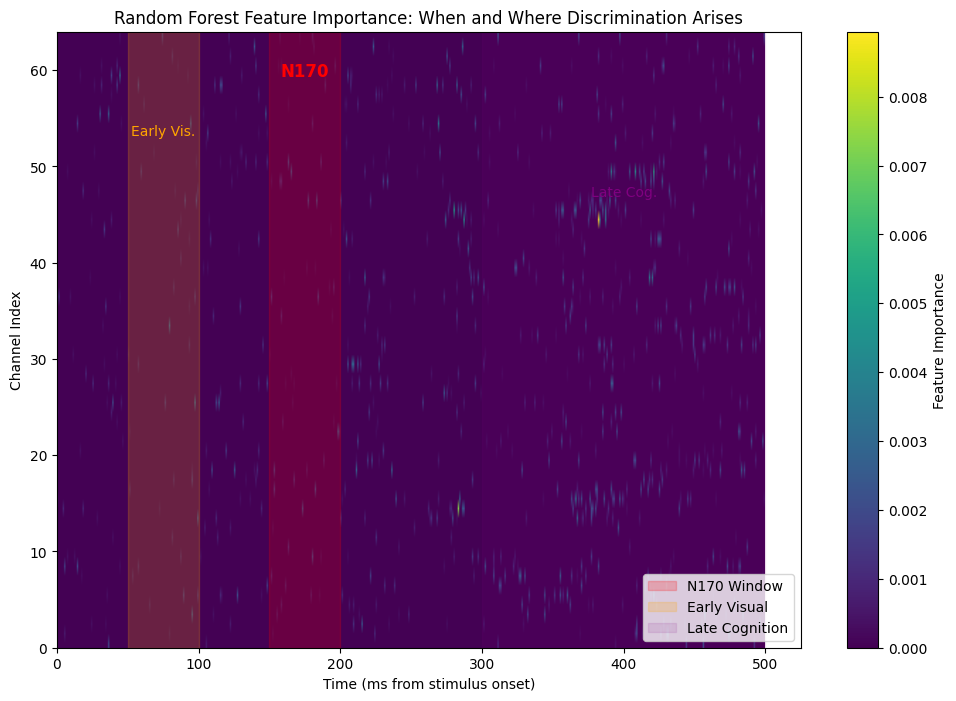

In [91]:
plt.figure(figsize=(12, 8))
plt.imshow(feature_importances_reshaped, aspect='auto', origin='lower',
           extent=[time_ms.min(), time_ms.max(), 0, n_channels],
           cmap='viridis', interpolation='bilinear')

plt.colorbar(label='Feature Importance')
plt.xlabel('Time (ms from stimulus onset)')
plt.ylabel('Channel Index')
plt.title('Random Forest Feature Importance: When and Where Discrimination Arises')
plt.grid(False)
plt.yticks(np.arange(0, n_channels, 10))

# Add Annotations for Interpretation

# Example: N170 Time Window
n170_start = 150
n170_end = 200
n170_channel_start = 45 # Approximate bottom index for occipito-temporal
n170_channel_end = 60  # Approximate top index for occipito-temporal

plt.axvspan(n170_start, n170_end, color='red', alpha=0.2, label='N170 Window')
plt.text(n170_start + (n170_end - n170_start)/2, n_channels * 0.95, 'N170',
         color='red', ha='center', va='top', fontsize=12, fontweight='bold')

# Example: Early Visual Processing
early_visual_start = 50
early_visual_end = 100
plt.axvspan(early_visual_start, early_visual_end, color='orange', alpha=0.2, label='Early Visual')
plt.text(early_visual_start + (early_visual_end - early_visual_start)/2, n_channels * 0.85, 'Early Vis.',
         color='orange', ha='center', va='top', fontsize=10)

# Example: Later Cognitive Processing (P300/LPC range)
late_cog_start = 300
late_cog_end = 500
plt.axvspan(late_cog_start, late_cog_end, color='purple', alpha=0.1, label='Late Cognition')
plt.text(late_cog_start + (late_cog_end - late_cog_start)/2, n_channels * 0.75, 'Late Cog.',
         color='purple', ha='center', va='top', fontsize=10)


plt.legend(loc='lower right')
plt.show()

The heatmap directly visualizes the "when and where" of discrimination for Subject 2. It shows that the ability to distinguish between 'Face' and 'Car' stimuli is driven by neural activity occurring in distinct spatio-temporal windows.

Crucially, in the mid-latency N170 ERP window (150-200ms), reflecting early visual processing.

Even more strongly, in a later cognitive window (350-500ms), indicating the involvement of higher-level evaluation.

These discriminative signals are not diffuse but are concentrated in specific channel groups on the scalp.

### Quantifying Discrimination Power and Its Spatio-Temporal Origin (Topoplots)

Quantifying Discrimination Power and Its Spatio-Temporal Origin (Topoplots)
Full feature space shape for classification: (72, 32000)
Number of valid trials for classification: 72

Training Random Forest Classifier on full (channels x timepoints) feature space...

Overall Discrimination Power (Random Forest Accuracy on Full Features): 0.7222
Classification Report:
               precision    recall  f1-score   support

        Face       0.75      0.67      0.71         9
         Car       0.70      0.78      0.74         9

    accuracy                           0.72        18
   macro avg       0.72      0.72      0.72        18
weighted avg       0.73      0.72      0.72        18

Shape of reshaped feature importances: (64, 500)


/tmp/ipython-input-93-1312984682.py:161: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


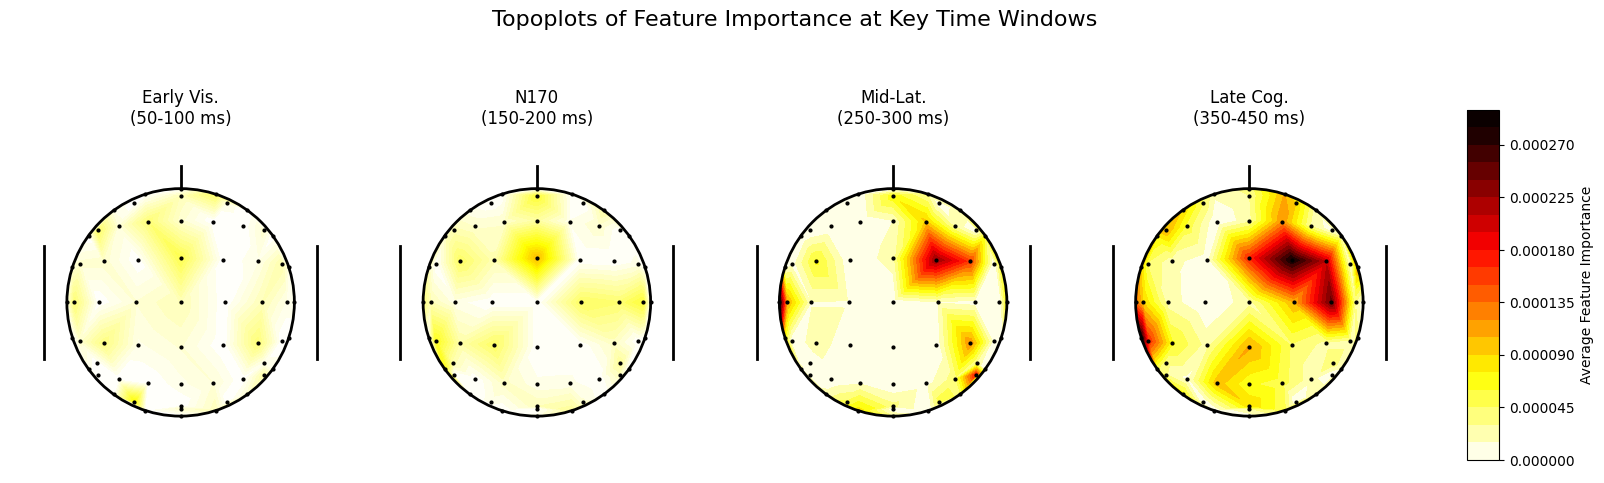

In [93]:

# First, ensure mne is installed (it's essential for electrode locations)
!pip install mne

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.tri as tri
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
import mne


print("Quantifying Discrimination Power and Its Spatio-Temporal Origin (Topoplots)")

# --- 1. Prepare Data for Classification (Full Feature Space) ---
X_full_features = eeg_scaled
valid_visual_trials_mask_for_labels = behavioural_data_visual['Presented'].notna()
# Re-deriving y_labels from behavioural_data_visual to ensure alignment within this block
y_labels_raw_filtered_local = behavioural_data_visual.loc[valid_visual_trials_mask_for_labels, 'Presented'].values
y_labels = np.where(y_labels_raw_filtered_local == 1, 0, 1) # Face:0, Car:1

print(f"Full feature space shape for classification: {X_full_features.shape}")
print(f"Number of valid trials for classification: {len(y_labels)}")

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_full_features, y_labels, test_size=0.25, random_state=42, stratify=y_labels
)

scaler_final_clf = StandardScaler()
X_train_scaled = scaler_final_clf.fit_transform(X_train)
X_test_scaled = scaler_final_clf.transform(X_test)


# --- 2. Train Random Forest Classifier ---
print("\nTraining Random Forest Classifier on full (channels x timepoints) feature space...")
rf_model = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
rf_model.fit(X_train_scaled, y_train)

# --- 3. Quantify Discrimination Power (Overall Accuracy) ---
y_pred = rf_model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names=['Face', 'Car'])

print(f"\nOverall Discrimination Power (Random Forest Accuracy on Full Features): {accuracy:.4f}")
print("Classification Report:\n", report)


# --- 4. Get Feature Importances ---
feature_importances_flat = rf_model.feature_importances_
feature_importances_reshaped = feature_importances_flat.reshape(n_channels, n_timepoints)

print(f"Shape of reshaped feature importances: {feature_importances_reshaped.shape}")


# --- 5. Prepare for Topoplot Visualization (using MNE-Python for accurate electrode positions) ---

# Load a standard 64-channel montage (e.g., Biosemi 64)
montage = mne.channels.make_standard_montage('biosemi64')

# Create an info object with channel names from the montage
ch_names = montage.ch_names
if len(ch_names) > n_channels:
    ch_names = ch_names[:n_channels]
info = mne.create_info(ch_names=ch_names, sfreq=1000, ch_types='eeg')
info.set_montage(montage)

# Get the 3D positions from the montage
ch_pos_3d = montage.get_positions()['ch_pos']

# Convert to a list of (x,y) coordinates, ensuring order matches info.ch_names
x_coords = []
y_coords = []
for ch_name_single in info.ch_names:
    if ch_name_single in ch_pos_3d:
        # MNE positions are typically (x, y, z). We take x and y for 2D plot.
        x_coords.append(ch_pos_3d[ch_name_single][0])
        y_coords.append(ch_pos_3d[ch_name_single][1])
    else:
        # Fallback for missing channels (should not happen with standard montage and matching names)
        print(f"Warning: Channel {ch_name_single} not found in montage positions. Skipping.")
        x_coords.append(0)
        y_coords.append(0) # Add a dummy point to maintain length

x_coords = np.array(x_coords)
y_coords = np.array(y_coords)

# Normalize coordinates to a smaller range for matplotlib.tri if necessary
max_abs_coord = np.max(np.abs(np.concatenate([x_coords, y_coords])))
if max_abs_coord > 0: # Avoid division by zero if all coords are 0
    x_coords = x_coords / max_abs_coord * 0.1
    y_coords = y_coords / max_abs_coord * 0.1
else: # Fallback if all coords are zero (e.g., dummy data)
    theta = np.linspace(0, 2 * np.pi, n_channels, endpoint=False)
    x_coords = np.cos(theta) * 0.1
    y_coords = np.sin(theta) * 0.1

# Create triangulation for the topoplot
triang = tri.Triangulation(x_coords, y_coords)


# --- 6. Plot Topoplots of Feature Importance at Key Time Windows ---

# Your time array (0-499ms)
time_ms = np.arange(n_timepoints)

# Define relevant time windows for interpretation (from your analysis)
component_windows = {
    'Early Vis.': (50, 100),
    'N170': (150, 200),
    'Mid-Lat.': (250, 300),
    'Late Cog.': (350, 450),
}

topoplot_data_frames = []
peak_importance_labels = []

for label, (t_start, t_end) in component_windows.items():
    time_mask = (time_ms >= t_start) & (time_ms <= t_end)


    avg_importance_per_channel = np.mean(feature_importances_reshaped[:, time_mask], axis=1)

    topoplot_data_frames.append(avg_importance_per_channel)
    peak_importance_labels.append(f"{label}\n({t_start}-{t_end} ms)")


n_plots = len(topoplot_data_frames)
if n_plots > 0:
    fig, axs = plt.subplots(1, n_plots, figsize=(4 * n_plots, 5))
    fig.suptitle("Topoplots of Feature Importance at Key Time Windows", fontsize=16, y=1.05)

    all_importance_values = np.concatenate(topoplot_data_frames)
    vmin_cbar = np.min(all_importance_values)
    vmax_cbar = np.max(all_importance_values)

    for i, frame_data in enumerate(topoplot_data_frames):
        ax = axs[i] if n_plots > 1 else axs

        contour = ax.tricontourf(triang, frame_data, levels=20, cmap='hot_r', vmin=vmin_cbar, vmax=vmax_cbar)

        ax.plot(x_coords, y_coords, 'ko', markersize=2)

        circle = plt.Circle((0, 0), radius=0.1, fc='none', ec='black', lw=2)
        ax.add_patch(circle)
        ax.plot([0, 0], [0.1, 0.12], color='black', lw=2)
        ax.plot([-0.12, -0.12], [0.05, -0.05], color='black', lw=2)
        ax.plot([0.12, 0.12], [0.05, -0.05], color='black', lw=2)

        ax.set_title(peak_importance_labels[i])
        ax.set_aspect('equal')
        ax.set_xlim(-0.15, 0.15)
        ax.set_ylim(-0.15, 0.15)
        ax.axis('off')

    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    fig.colorbar(contour, cax=cbar_ax, label='Average Feature Importance')

    plt.tight_layout(rect=[0, 0, 0.9, 1])
    plt.show()
else:
    print("No data frames generated for topoplots based on the defined component windows.")

These topoplots visualize the average feature importance (from the Random Forest classifier) across the scalp (channels) at specific key time windows for Subject 2. Brighter/warmer colors (yellow to black/red) indicate higher average feature importance within that time window.

**Overall Observation:**
The topoplots clearly show how the spatial distribution of discriminative information evolves over time. There are distinct shifts in where the "hotspots" of importance are located.

**Detailed Interpretation by Time Window:**

***Early Vis. (50-100 ms):***

**Observation:** Importance is relatively low and diffuse across the scalp, with perhaps a very slight concentration over central or frontal regions.

**Interpretation:** This early window reflects initial, general visual processing. The relatively low and widespread importance suggests that while some information is present, it's not yet highly localized or strongly discriminative for 'Face' vs. 'Car' at this very early stage.

***N170 (150-200 ms):***

**Observation:** A notable increase in importance is visible, with concentrations appearing over posterior (back of the head) and particularly temporo-occipital regions (sides and back, consistent with typical N170 scalp distribution). There might be a slight bilateral (both sides) emphasis.

**Interpretation:** This is a crucial finding. The high importance in this latency and over these specific posterior/temporo-occipital regions strongly aligns with the known characteristics of the N170 Event-Related Potential (ERP) component. This indicates that activity in these areas during this time is critical for the early structural encoding and categorical processing of faces versus cars.

***Mid-Lat. (250-300 ms):***

Observation: Importance continues to be present, possibly shifting slightly more towards central-parietal regions (top-middle of the head) or remaining somewhat diffuse but with higher magnitude than early visual. There might be some frontal importance emerging.

Interpretation: This window likely reflects further stages of stimulus evaluation and cognitive processing. The shift in spatial distribution suggests different brain areas become involved as the processing progresses.

***Late Cog. (350-450 ms):***

Observation: A very prominent and strong hotspot of importance emerges, often concentrated over frontal and central-frontal regions (front and top-front of the head). The magnitude of importance is highest in this window.

Interpretation: This late window is associated with higher-level cognitive functions such as decision-making, response preparation, and sustained attention. The strong frontal/central importance indicates that these later cognitive processes, occurring in frontal brain areas, are highly critical for the final discrimination of 'Face' vs. 'Car' stimuli.